In [1]:
import os, io, json, base64, re
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

import matplotlib.pyplot as plt
import matplotlib as mpl
import folium
from folium import GeoJson
from folium.plugins import FastMarkerCluster
from branca.element import Element, MacroElement, Template
mpl.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"],
                     "axes.unicode_minus": False,})

In [2]:
df = pd.read_csv("./data/final_df.csv")

In [3]:
# import re, time, requests
# import pandas as pd, numpy as np
 
# df1 = pd.read_csv("./data/big_data_set1_2.csv", encoding="cp949") 
# df2 = pd.read_csv("./data/big_data_set2.csv", encoding="cp949")
# df3 = pd.read_csv("./data/big_data_set3.csv", encoding="cp949")

# df1_sd = df1[df1["MCT_BSE_AR"].astype(str).str.contains("성동구", na=False)].copy()

# addr_base = (df1_sd["MCT_BSE_AR"].astype(str)
#              .str.replace(r"^서울\s*특별시|^서울시|^서울\b", "서울특별시", regex=True)
#              .str.replace(r"\.+$", "", regex=True)
#              .str.replace(r"\s+", " ", regex=True).str.strip())
# df1_sd["ADDR_QUERY"] = addr_base 

# KEY = "devU01TX0FVVEgyMDI1MDkyMzIyMjI0ODExNjI1ODY=" 
# URL = "https://business.juso.go.kr/addrlink/addrLinkApi.do"

# def juso_lookup(q):
#     p = {"confmKey":KEY, "currentPage":1, "countPerPage":5, "keyword":q, "resultType":"json"}
#     d = requests.get(URL, params=p, timeout=5).json()
#     cand = d.get("results", {}).get("juso", []) or []
#     cand = [c for c in cand if c.get("sggNm") == "성동구"] or cand
#     if not cand:
#         return {"road":"", "jibun":"", "dong":""}
#     j = cand[0]
#     return {"road": j.get("roadAddr",""),
#             "jibun":j.get("jibunAddr",""),
#             "dong": j.get("emdNm","")}

# uniq = df1_sd["ADDR_QUERY"].dropna().unique().tolist()
# res_map = {}
# for i, a in enumerate(uniq, 1):
#     res_map[a] = juso_lookup(a)
#     time.sleep(2) 

# df1_sd["_ROAD_RAW"]  = df1_sd["ADDR_QUERY"].map(lambda a: res_map.get(a, {}).get("road", ""))
# df1_sd["_JIBUN_RAW"] = df1_sd["ADDR_QUERY"].map(lambda a: res_map.get(a, {}).get("jibun", ""))
# df1_sd["DONG"]       = df1_sd["ADDR_QUERY"].map(lambda a: res_map.get(a, {}).get("dong", ""))

# def clean_addr(s):
#     return (s.fillna("").astype(str)
#              .str.replace(r"\s*\([^)]*\)\s*", " ", regex=True)
#              .str.replace(r"^서울\s*특별시|^서울시|^서울\b", "서울특별시", regex=True)
#              .str.replace(r"\.+$", "", regex=True)
#              .str.replace(r"\s+", " ", regex=True).str.strip())

# def clean_jibun_to_lot_only(s):
#     base = (s.fillna("").astype(str)
#              .str.replace(r"\s*\([^)]*\)\s*", " ", regex=True)    
#              .str.replace(r"[，,].*$", "", regex=True)         
#              .str.replace(r"\.+$", "", regex=True)
#              .str.replace(r"\s+", " ", regex=True)
#              .str.strip()
#              .str.replace(r"^서울\s*특별시|^서울시|^서울\b", "서울특별시", regex=True))
#     pat = re.compile(r'^(.*?\s(?:산\s*)?\d+(?:-\d+)?(?:번지)?)\b')
#     def _cut(x):
#         m = pat.search(x)
#         return m.group(1) if m else x
#     return base.map(_cut)

# cond = df1_sd["_ROAD_RAW"].astype(str).str.len() > 0
# df1_sd["ADDR_ROAD"] = clean_addr(df1_sd["_ROAD_RAW"].where(cond, df1_sd["ADDR_QUERY"]))

# df1_sd["ADDR_JIBUN"] = clean_jibun_to_lot_only(df1_sd["_JIBUN_RAW"])

# def extract_dong_from_any(x):
#     s = "" if pd.isna(x) else str(x)
#     m = re.search(r"성동구\s*([^\s]+동)\b", s)
#     if m: return m.group(1)
#     m = re.search(r"\(([^)]+동)\b", s)
#     return m.group(1) if m else ""

# df1_sd["DONG"] = df1_sd["DONG"].replace("", np.nan)
# df1_sd["DONG"] = df1_sd["DONG"].fillna(df1_sd["_JIBUN_RAW"].map(extract_dong_from_any))
# df1_sd["DONG"] = df1_sd["DONG"].fillna(df1_sd["_ROAD_RAW"].map(extract_dong_from_any))

# df1_sd.drop(columns=["_ROAD_RAW","_JIBUN_RAW","ADDR_QUERY","MCT_BSE_AR"], inplace=True)
# df1_sd.to_csv("./data/set1_update.csv", index=False, encoding="cp949")

In [4]:
# IN_PATH  = os.environ.get("IN_PATH",  "./data/set1_update.csv")
# OUT_PATH = os.environ.get("OUT_PATH", "./data/set1_update_with_coord.csv")
# CACHE    = os.environ.get("CACHE",    "./data/geocode_cache_kakao.json")
# KAKAO_KEY = "28e74d83b10673ec5ffb63b68bad10d6"  

# def make_query(row):
#     for k in ("ADDR_ROAD","ADDR_JIBUN","DONG","ADDR_Q"):
#         v = str(row.get(k, "")).strip() if k in row else ""
#         if v and v.lower()!="nan":
#             if k=="DONG" and not v.startswith("서울특별시"):
#                 return f"서울특별시 성동구 {v}"
#             return v
#     return ""

# def geocode_kakao_addr(q, key):
#     url = "https://dapi.kakao.com/v2/local/search/address.json"
#     headers = {"Authorization": f"KakaoAK {key}"}
#     params  = {"query": q, "analyze_type": "similar", "page": 1, "size": 5}
#     try:
#         r = requests.get(url, headers=headers, params=params, timeout=6)
#         r.raise_for_status()
#         docs = r.json().get("documents", [])
#         if not docs:
#             return None
#         d = docs[0]
#         return {"lat": float(d["y"]),
#                 "lon": float(d["x"]),
#                 "provider": "kakao_addr",
#                 "level": d.get("address_type",""),
#                 "conf": 0.7 if d.get("address_type")=="ROAD_ADDR" else 0.6}
#     except Exception:
#         return None

# def geocode_kakao_keyword(q, key):
#     url = "https://dapi.kakao.com/v2/local/search/keyword.json"
#     headers = {"Authorization": f"KakaoAK {key}"}
#     params  = {"query": q, "page": 1, "size": 5}
#     try:
#         r = requests.get(url, headers=headers, params=params, timeout=6)
#         r.raise_for_status()
#         docs = r.json().get("documents", [])
#         if not docs:
#             return None
#         d = docs[0]
#         return {"lat": float(d["y"]),
#                 "lon": float(d["x"]),
#                 "provider": "kakao_keyword",
#                 "level": "PLACE",
#                 "conf": 0.6}
#     except Exception:
#         return None

# def geocode(q, key):
#     a = geocode_kakao_addr(q, key)
#     if a: return a
#     time.sleep(1)
#     return geocode_kakao_keyword(q, key)

# def main():
#     if not KAKAO_KEY:
#         raise SystemExit("KAKAO_REST_KEY 환경변수가 비어 있습니다.")

#     df = pd.read_csv(IN_PATH, encoding="cp949")
#     if "ADDR_Q" not in df.columns:
#         df["ADDR_Q"] = df.apply(make_query, axis=1)
#     uniq = [q for q in df["ADDR_Q"].dropna().unique().tolist() if q]

#     try:
#         cache = json.load(open(CACHE, "r", encoding="utf-8"))
#     except Exception:
#         cache = {}

#     for i, q in enumerate(uniq, 1):
#         if q not in cache:
#             ans = geocode(q, KAKAO_KEY)
#             if ans is None:
#                 ans = {"lat": None, "lon": None, "provider":"", "level":"", "conf":0.0}
#             cache[q] = ans
#             if i % 30 == 0:
#                 json.dump(cache, open(CACHE, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
#             time.sleep(1)
#         if i % 200 == 0:
#             print(f"… processed {i}/{len(uniq)} unique queries")

#     json.dump(cache, open(CACHE, "w", encoding="utf-8"), ensure_ascii=False, indent=2)

#     def get_field(q, k):
#         try: return cache.get(q, {}).get(k, None)
#         except: return None

#     df["LAT"]        = df["ADDR_Q"].map(lambda q: get_field(q, "lat"))
#     df["LON"]        = df["ADDR_Q"].map(lambda q: get_field(q, "lon"))
#     df["GEO_SOURCE"] = df["ADDR_Q"].map(lambda q: cache.get(q, {}).get("provider",""))   # kakao_addr / kakao_keyword
#     df["GEO_LEVEL"]  = df["ADDR_Q"].map(lambda q: cache.get(q, {}).get("level",""))      # ROAD_ADDR > REGION_ADDR/PLACE (정밀도)
#     df["GEO_CONF"]   = df["ADDR_Q"].map(lambda q: cache.get(q, {}).get("conf",0.0))      #    0.7             0.6        (신뢰도)
#     df["GEO_OK"]     = df["LAT"].notna() & df["LON"].notna()                             # 좌표 여부 : T/F 
#     df["GEO_WEAK"]   = df["GEO_CONF"].fillna(0) < 0.5

#     df.to_csv(OUT_PATH, index=False, encoding="cp949")
#     hit = float(df["GEO_OK"].mean()*100)
#     print(f"Saved: {OUT_PATH}  | rows={len(df)}  | geocoding hit = {hit:.1f}%")

# if __name__ == "__main__":
#     main()

In [5]:
# import os, json
# import pandas as pd
# import numpy as np
# from shapely.geometry import shape, Point
# from shapely.strtree import STRtree

# DF_PATH       = "./data/final_df.csv"   
# DONG_GEOJSON  = "./data/administrative_district/4_서울시_행정동/서울_행정동_경계_2017.geojson"
# OUT_CSV       = "./data/seongdong_final.csv"
# TARGET_SIDO   = "서울특별시"
# TARGET_GU     = "성동구"

# os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)

# # 데이터 읽기 
# def read_df_any(path):
#     for enc in ("cp949","utf-8-sig","utf-8"):
#         try:
#             return pd.read_csv(path, encoding=enc, low_memory=False)
#         except Exception:
#             continue
#     raise RuntimeError(f"CSV 읽기 실패: {path}")

# df = read_df_any(DF_PATH)

# # 위/경도 컬럼 자동 인식
# lat_cands = ["위도","lat","LAT","Latitude","latitude","Y","y"]
# lon_cands = ["경도","lon","LON","Longitude","longitude","X","x"]
# def pick(cands, cols):
#     for c in cands:
#         if c in cols: return c
#     return None

# LAT_COL = pick(lat_cands, df.columns)
# LON_COL = pick(lon_cands, df.columns)
# if LAT_COL is None or LON_COL is None:
#     raise ValueError(f"위도/경도 컬럼을 찾을 수 없습니다: {list(df.columns)}")

# pts = df[[LAT_COL, LON_COL]].copy().rename(columns={LAT_COL:"lat", LON_COL:"lon"})
# pts = pts.replace([np.inf,-np.inf], np.nan)
# pts["lat"] = pd.to_numeric(pts["lat"], errors="coerce")
# pts["lon"] = pd.to_numeric(pts["lon"], errors="coerce")

# # 행정동 경계 로드 & 성동구만 필터 
# with open(DONG_GEOJSON, "r", encoding="utf-8") as f:
#     gj = json.load(f)

# features = [ft for ft in gj["features"]
#             if (TARGET_SIDO in ft.get("properties",{}).get("adm_nm",""))
#             and (TARGET_GU   in ft.get("properties",{}).get("adm_nm",""))]

# geoms = [shape(ft["geometry"]) for ft in features]
# props = [ft.get("properties", {}) for ft in features]
# tree  = STRtree(geoms)                    
# id_to_idx = {id(g): i for i,g in enumerate(geoms)}  

# # 포인트 → 행정동 매핑 (버전 호환) 
# adm_full = []; gu_list=[]; dong_list=[]

# for lat, lon in zip(pts["lat"], pts["lon"]):
#     if not (pd.notna(lat) and pd.notna(lon)):
#         adm_full.append(None); gu_list.append(None); dong_list.append(None); 
#         continue

#     p = Point(float(lon), float(lat))  
#     cand = tree.query(p)               

#     # 결과를 '인덱스 리스트'로 정규화
#     idx_list = []
#     if len(cand) > 0:
#         first = cand[0]
#         if isinstance(first, (int, np.integer)):  
#             idx_list = [int(i) for i in np.array(cand).ravel().tolist()]
#         else:                                   
#             idx_list = [id_to_idx[id(g)] for g in cand]

#     matched_idx = None
#     for idx in idx_list:
#         gpoly = geoms[idx]
#         if gpoly.contains(p):                   
#             matched_idx = idx
#             break

#     if matched_idx is None:
#         adm_full.append(None); gu_list.append(None); dong_list.append(None)
#     else:
#         nm = props[matched_idx].get("adm_nm","")
#         toks = str(nm).split()
#         gname = toks[1] if len(toks) >= 2 else ""
#         dname = toks[-1] if len(toks) >= 3 else ""
#         adm_full.append(nm); gu_list.append(gname); dong_list.append(dname)

# df_out = df.copy()
# df_out["adm_nm_full"] = adm_full
# df_out["자치구"] = gu_list
# df_out["행정동"] = dong_list

# df_out.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

In [6]:
# 업종 중분류 분리
MIDMAP = {# 한식
          "한식-육류/고기":"한식",    "백반/가정식":"한식",    "한정식":"한식",    
          "한식-해물/생선":"한식",    "한식-감자탕":"한식",    "한식뷔페":"한식",  
          "한식-찌개/전골":"한식",    "한식-냉면":"한식",      "기사식당":"한식",
          "한식-국수/만두":"한식",    "한식-죽":"한식",        "한식-두부요리":"한식",
          "한식-단품요리일반":"한식", "한식-국밥/설렁탕":"한식",
           
          # 양식/서양
          "양식":"양식/서양", "스테이크":"양식/서양",

          # 중식
          "중식당":"중식", "중식-훠궈/마라탕":"중식", "중식-딤섬/중식만두":"중식",

          # 일식
          "일식당":"일식",             "일식-초밥/롤":"일식",     "일식-참치회":"일식",
          "일식-우동/소바/라면":"일식", "일식-덮밥/돈가스":"일식", "일식-샤브샤브":"일식", 

          # 아시아/세계
          "동남아/인도음식":"아시아/세계", "기타세계요리":"아시아/세계",
          
          # 간편식/분식/도시락
          "분식":"간편식", "도시락":"간편식", "샌드위치/토스트":"간편식", 

          # 패스트푸드 
          "치킨":"패스트푸드", "피자":"패스트푸드", "햄버거":"패스트푸드",  

          # 카페/음료
          "카페":"카페/음료",  "커피전문점":"카페/음료",  "테이크아웃커피":"카페/음료", 
          "주스":"카페/음료",  "차":"카페/음료",         "테마카페":"카페/음료", 

          # 디저트/베이커리
          "베이커리":"디저트/베이커리",  "와플/크로플":"디저트/베이커리",  "아이스크림/빙수":"디저트/베이커리",
          "도너츠":"디저트/베이커리",    "탕후루":"디저트/베이커리",  
          "마카롱":"디저트/베이커리",    "떡/한과":"디저트/베이커리",      

          # 주점/주류
          "포장마차":"주점/주류업장",  "이자카야":"주점/주류업장",      "호프/맥주":"주점/주류업장",    
          "요리주점":"주점/주류업장",  "꼬치구이":"주점/주류업장",      "와인바":"주점/주류업장",
          "민속주점":"주점/주류업장",  "일반 유흥주점":"주점/주류업장",  "룸살롱/단란주점":"주점/주류업장",

          # 구내식당/푸드코트
          "구내식당/푸드코트":"구내식당/푸드코트",  
          
          # 반찬
          "반찬": "반찬",

          # 식품/식자재 
          "축산물":"식품/식자재",  "식료품":"식품/식자재",  "농산물":"식품/식자재",  "청과물":"식품/식자재",
          "수산물":"식품/식자재",  "건어물":"식품/식자재",  "미곡상":"식품/식자재",  "유제품":"식품/식자재", 

          # 주류/와인샵
          "와인샵":"주류",  "주류":"주류",  "담배":"담배",

          # 건강/특수식품
          "인삼제품":"건강식품/건강원", "건강식품":"건강식품/건강원", "건강원":"건강식품/건강원",

          # 제조/기타
          "식품 제조":"식품제조",  "떡/한과 제조":"식품제조",  "None":"None"}

df["업종중분류"] = df["업종"].map(MIDMAP).fillna("기타(미정)")

EXCLUDE_MIDS = {"주류","담배","식품제조","건강식품/건강원"}
df = df[~df["업종중분류"].isin(EXCLUDE_MIDS)].reset_index(drop=True)

In [7]:
def ym_to_dt(ym):
    ym = ym.astype(str).str.zfill(6)
    return pd.to_datetime(ym + "01", format="%Y%m%d", errors="coerce")

def ymd_float_to_dt(s):
    s_num = pd.to_numeric(s, errors="coerce")        
    s_str = s_num.dropna().astype(np.int64).astype(str).str[:8]
    out = pd.Series(pd.NaT, index=s.index)
    out.loc[s_str.index] = pd.to_datetime(s_str, format="%Y%m%d", errors="coerce")
    return out

def month_diff(d1, d2):
    y1, m1 = d1.dt.year, d1.dt.month
    y2, m2 = d2.dt.year, d2.dt.month
    return (y2 - y1) * 12 + (m2 - m1)

df = df.copy()

# 날짜 파싱
df["dt"] = ym_to_dt(df["기준년월"])
df["open_dt"] = ymd_float_to_dt(df["개설일"])
df["close_dt"] = ymd_float_to_dt(df["폐업일"])

# 운영개월수/해당월 폐업 여부
df["tenure_m"] = month_diff(df["open_dt"], df["dt"]).clip(lower=0)
df["is_closed_this_month"] = (df["close_dt"].dt.to_period("M") == df["dt"].dt.to_period("M")).astype(int)

# 연/월/분기 
df["year"] = df["dt"].dt.year.astype("Int16")
df["month"] = df["dt"].dt.month.astype("Int8")
df["quarter"]= df["dt"].dt.quarter.astype("Int8")

# 계절 라벨 (winter/spring/summer/autumn)
season_map = {12:"winter", 1:"winter", 2:"winter", 3:"spring", 4:"spring", 5:"spring",
               6:"summer", 7:"summer", 8:"summer", 9:"autumn",10:"autumn",11:"autumn"}

df["season"] = pd.Categorical(df["month"].map(season_map), categories=["winter","spring","summer","autumn"])

In [8]:
def find_ratio_like_cols(df):
    pat = re.compile(r"(비율|비중|순위\s*비율)")
    # 숫자형이거나 숫자로 무리 없이 캐스팅 가능한 열만 후보
    candidates = []
    for c in df.columns:
        name_hit = bool(pat.search(str(c)))
        if not name_hit:
            continue
        # 날짜/카테고리/객체는 제외
        if pd.api.types.is_datetime64_any_dtype(df[c]) or pd.api.types.is_period_dtype(df[c]):
            continue
        if pd.api.types.is_categorical_dtype(df[c]):
            continue
        candidates.append(c)
    return candidates

def clean_ratio_like(df, sentinel=-999_999.9, clip01=True):
    out = df.copy()
    ratio_cols = find_ratio_like_cols(out)

    report = []
    for c in ratio_cols:
        s = pd.to_numeric(out[c], errors="coerce")
        n_total = s.size
        n_sentinel = int((s == sentinel).sum())
        s = s.mask(s == sentinel, np.nan)

        if clip01:
            out_of_range = (~s.between(0, 100)).sum(skipna=True)
            s = s.mask(~s.between(0, 100))
            s = s.clip(lower=0, upper=100)

        out[c] = s.astype(float)
        report.append((c, n_total, n_sentinel, int(out_of_range if clip01 else 0)))

    print("[정리 요약] (컬럼, 총건수, 센티넬개수, 범위밖개수)")
    for c, n_total, n_sent, n_oob in report:
        print(f"- {c}\t{n_total}\t{n_sent}\t{n_oob}")

    return out, ratio_cols

In [9]:
# # 고객 연령구성/유입 경로 다양성(엔트로피)
# male_cols = ["남성 20대이하 고객 비중","남성 30대 고객 비중","남성 40대 고객 비중","남성 50대 고객 비중","남성 60대이상 고객 비중"]
# fem_cols = ["여성 20대이하 고객 비중","여성 30대 고객 비중","여성 40대 고객 비중","여성 50대 고객 비중","여성 60대이상 고객 비중"]
# age_cols = male_cols + fem_cols
# inflow_cols = ["거주 이용 고객 비율","직장 이용 고객 비율","유동인구 이용 고객 비율"]

# def entropy_row(vals):
#     p = np.clip(np.array(vals, dtype=float), 0, 1)
#     s = p.sum()
#     if s <= 0: 
#         return 0.0
#     p = p / s
#     p = np.where(p>0, p, 1)
#     return -np.sum(p * np.log(p))

# df["cust_age_entropy"] = df[age_cols].apply(entropy_row, axis=1)
# df["cust_source_entropy"] = df[inflow_cols].apply(entropy_row, axis=1)

In [10]:
# #업종×행정동 규모/점유
# #  mid_share_in_dong: 행정동 내 업종의 점유율
# #  - dong_store_cnt: 해당 행정동의 전체 유니크 점포 수
# #  - mid_dong_store_cnt: (업종중분류, 행정동)그룹의 유니크 점포 수

# df["dong_store_cnt"] = df.groupby(["행정동"])["가맹점번호"].transform("nunique")
# df["mid_dong_store_cnt"] = df.groupby(["업종중분류","행정동"])["가맹점번호"].transform("nunique")
# df["mid_share_in_dong"] = (df["mid_dong_store_cnt"] / df["dong_store_cnt"]).replace([np.inf, -np.inf], np.nan)

# # 행정동 내 업종 점유율(mid_share_in_dong) 히스토그램
# plt.figure(figsize=(6,4))
# plt.hist(pd.to_numeric(df["mid_share_in_dong"], errors="coerce").dropna(), bins=40)
# plt.title("Histogram — mid_share_in_dong"); plt.xlabel("share"); plt.ylabel("rows")
# plt.tight_layout(); plt.show()

In [11]:
# # 안전 보정(숫자형/NaN/∞) 
# for c in ["mid_dong_store_cnt","dong_store_cnt","mid_share_in_dong"]:
#     if c in df.columns:
#         df[c] = pd.to_numeric(df[c], errors="coerce")
# df["mid_share_in_dong"] = df["mid_share_in_dong"].replace([np.inf,-np.inf], np.nan).clip(0,1)
# df["_dong_total"] = df.groupby("행정동")["dong_store_cnt"].transform("max")

# # 피벗(전체 행정동 × 전체 업종중분류) 
# pivot = df.pivot_table(index="행정동", columns="업종중분류", values="mid_share_in_dong", aggfunc="mean")

# # 정렬 + 교집합 처리
# dong_sort = (df.loc[df["mid_share_in_dong"].notna()].groupby("행정동")["_dong_total"].max().sort_values(ascending=False).index)
# pivot = pivot.reindex(dong_sort.intersection(pivot.index))
# mid_sort = pivot.mean(axis=0, skipna=True).sort_values(ascending=False).index
# pivot = pivot.loc[:, mid_sort]


# # 업종×행정동 히트맵 
# fig, ax = plt.subplots(figsize=(16, 9))
# im = ax.imshow(pivot.values, aspect="auto", vmin=0, vmax=1, cmap="Blues")
# ax.set_xticks(np.arange(pivot.shape[1])); ax.set_xticklabels(pivot.columns, rotation=60, ha="right")
# ax.set_yticks(np.arange(pivot.shape[0])); ax.set_yticklabels(pivot.index)
# ax.set_title("업종×행정동 점유율 히트맵 (전체)")
# cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02); cbar.set_label("점유율")
# plt.tight_layout(); plt.show()


# # 행정동별 업종 점유율 스택 막대 
# wide = pivot.fillna(0)
# fig, ax = plt.subplots(figsize=(18, 7))
# bottom = np.zeros(wide.shape[0])
# for col in wide.columns:
#     ax.bar(wide.index, wide[col].values, bottom=bottom, label=col)
#     bottom += wide[col].values
# ax.set_title("행정동별 업종 점유율 스택 (전체 업종)")
# ax.set_ylabel("점유율"); ax.set_ylim(0, 1)
# ax.set_xticklabels(wide.index, rotation=60, ha="right")
# ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout(); plt.show()


# # 각 행정동 패널: '전 업종' 가로막대 
# DONGS = list(pivot.index)
# MIDS  = list(pivot.columns)
# COLS = 3
# rows = int(np.ceil(len(DONGS)/COLS))
# fig, axes = plt.subplots(rows, COLS, figsize=(COLS*6, rows*4), squeeze=False)

# for i, dong in enumerate(DONGS):
#     r, c = divmod(i, COLS); ax = axes[r, c]
#     s = pivot.loc[dong].dropna().sort_values(ascending=True)
#     ax.barh(s.index, s.values)
#     ax.set_title(f"[{dong}] 업종 점유율")
#     ax.set_xlim(0, 1); ax.set_xlabel("점유율")
#     for j, v in enumerate(s.values):
#         ax.text(v + 0.01, j, f"{v*100:.1f}%", va="center")
#     ax.margins(y=0.02)
# # 빈 패널 숨김
# for j in range(len(DONGS), rows*COLS):
#     r, c = divmod(j, COLS); axes[r, c].axis("off")

# fig.suptitle("행정동별 업종 점유율 (전체 업종)", y=1.02, fontsize=14)
# fig.tight_layout(); plt.show()


# # 각 업종 패널: 전 행정동 가로막대 
# COLS = 3
# rows = int(np.ceil(len(MIDS)/COLS))
# fig, axes = plt.subplots(rows, COLS, figsize=(COLS*6, rows*4), squeeze=False)

# for i, mid in enumerate(MIDS):
#     r, c = divmod(i, COLS); ax = axes[r, c]
#     s = pivot[mid].dropna().sort_values(ascending=True)
#     ax.barh(s.index, s.values)
#     ax.set_title(f"[{mid}] 행정동 점유율")
#     ax.set_xlim(0, 1); ax.set_xlabel("점유율")
#     for j, v in enumerate(s.values):
#         ax.text(v + 0.01, j, f"{v*100:.1f}%", va="center")
#     ax.margins(y=0.02)
# # 빈 패널 숨김
# for j in range(len(MIDS), rows*COLS):
#     r, c = divmod(j, COLS); axes[r, c].axis("off")

# fig.suptitle("업종중분류별 행정동 점유율 (전체 행정동)", y=1.02, fontsize=14)
# fig.tight_layout(); plt.show()

In [12]:
# # 행정동 내 업종 점유율 지도 시각화
# dfv = df.copy()
# dfv["위도"] = pd.to_numeric(dfv["위도"], errors="coerce")
# dfv["경도"] = pd.to_numeric(dfv["경도"], errors="coerce")

# # 전체기간 폐업 플래그 (가맹점 기준) 
# store_close_dt = dfv.groupby("가맹점번호", dropna=False)["close_dt"].max()

# store_any_flag = (
#     pd.Series(pd.to_datetime(store_close_dt, errors="coerce").notna(), index=store_close_dt.index)
#     .astype(int)
# )

# # 행 단위 매핑(0/1)
# dfv["__closed_any__"] = dfv["가맹점번호"].map(store_any_flag).fillna(0).astype(int)

# print("[검증] 전체기간 폐업(가맹점 고유) 수:", int(store_any_flag.sum()))
# print(dfv["__closed_any__"].value_counts(dropna=False))

# # 업종 팔레트 & 점유율 이미지 
# PALETTE = [
#     "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
#     "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf",
#     "#9edae5","#c7c7c7","#dbdb8d","#c49c94","#98df8a",
#     "#ff9896","#aec7e8","#ffbb78","#c5b0d5","#f7b6d2"
# ]
# mids = sorted(dfv["업종중분류"].dropna().unique().tolist())
# color_of = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(mids)}

# def share_series(g: pd.DataFrame) -> pd.Series:
#     if g.empty: return pd.Series(0, index=mids, dtype=float)
#     num = g["업종중분류"].value_counts()
#     den = len(g)
#     return (num/den).reindex(mids).fillna(0)

# def bar_png_datauri(title: str, s: pd.Series) -> str:
#     plt.figure(figsize=(4.9,3.2))
#     colors = [color_of.get(m, "#bbbbbb") for m in s.index]
#     if s.sum()==0:
#         plt.barh(s.index, [0.0001]*len(s), color="#e0e0e0", edgecolor="#cccccc")
#         plt.text(0.5, 0.5, "데이터 없음", ha="center", va="center",
#                  transform=plt.gca().transAxes, fontsize=13, color="#9e9e9e")
#     else:
#         plt.barh(s.index, s.values, color=colors)
#         for i, v in enumerate(s.values):
#             if v>0: plt.text(v+0.005, i, f"{v*100:.1f}%", va="center")
#     plt.xlim(0,1); plt.xlabel("점유율"); plt.title(title)
#     plt.tight_layout()
#     buf = io.BytesIO(); plt.savefig(buf, dpi=150, transparent=True, format="png"); plt.close()
#     return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

# dongs = sorted(dfv["행정동"].dropna().unique().tolist())
# IMG_SHARE = {"전체": bar_png_datauri("[전체] 업종 점유율", share_series(dfv))}
# IMG_SHARE_CLOSED = {"전체": bar_png_datauri("[전체-폐업(전체기간)] 업종 점유율",
#                                             share_series(dfv[dfv["__closed_any__"]==1]))}
# for dong in dongs:
#     g_all = dfv[dfv["행정동"]==dong]
#     IMG_SHARE[dong] = bar_png_datauri(f"[{dong}] 업종 점유율", share_series(g_all))
#     g_closed = g_all[g_all["__closed_any__"]==1]
#     IMG_SHARE_CLOSED[dong] = bar_png_datauri(f"[{dong}-폐업(전체기간)] 업종 점유율",
#                                              share_series(g_closed))

# # 지도 생성 (전체에서도 경계선/포인트 표시) 
# df_pts = dfv.dropna(subset=["위도","경도"]).copy()

# # 중심점
# if df_pts["위도"].notna().any():
#     lat0, lon0 = df_pts["위도"].mean(), df_pts["경도"].mean()
# else:
#     lat0, lon0 = 37.5636, 127.0364  # 성동구 근사 중심

# m = folium.Map(location=[lat0, lon0], zoom_start=13, tiles="CartoDB positron")

# # 성동구 경계 
# GJ_PATH = "./data/administrative_district/4_서울시_행정동/서울_행정동_경계_2017.geojson"
# if not os.path.exists(GJ_PATH):
#     raise FileNotFoundError(f"GeoJSON 파일을 찾을 수 없습니다: {GJ_PATH}")

# with open(GJ_PATH, "r", encoding="utf-8") as f:
#     gj = json.load(f)

# dong_full_set = set(("서울특별시 성동구 " + pd.Series(dongs)).astype(str))
# feats_sel = [ft for ft in gj.get("features", [])
#              if any(str(v) in dong_full_set for v in ft.get("properties",{}).values())]
# gj_sd = {"type":"FeatureCollection","features":feats_sel}

# def style_base(_): return {"fillColor":"#fffff0","fillOpacity":0.15,"color":"#333","weight":1.5}
# g_boundary = GeoJson(gj_sd, name="행정동 경계", style_function=style_base).add_to(m)
# try: m.fit_bounds(g_boundary.get_bounds(), max_zoom=15)
# except: pass

# # 전체 포인트(모든 월) → 클러스터
# cluster_points = df_pts[["위도","경도"]].values.tolist()
# cluster = FastMarkerCluster(cluster_points, name="전체(모든 월)", show=True)
# m.add_child(cluster)
# cluster_name = cluster.get_name()

# # 동별 포인트 데이터(모든 월): [lat, lon, mid, closed_any(0/1)]
# per_dong_jsdata_ALL = {}
# for dong, g in df_pts.groupby("행정동"):
#     per_dong_jsdata_ALL[dong] = [
#         [float(r["위도"]), float(r["경도"]), str(r["업종중분류"]), int(r["__closed_any__"])]
#         for _, r in g.iterrows()
#     ]

# # UI(드롭다운+차트 패널) 
# opts = "\n".join([f'<option value="{d}">{d}</option>' for d in dongs])
# m.get_root().html.add_child(Element(f"""
# <div style="position: fixed; top: 12px; right: 12px; z-index: 9999;
#  background: rgba(255,255,255,0.95); padding: 8px 10px; border: 1px solid #ccc;
#  border-radius: 8px; box-shadow: 0 2px 6px rgba(0,0,0,.15);">
#  <label style="font-weight:600;margin-right:6px;">행정동</label>
#  <select id="dongSelect"><option value="전체" selected>전체</option>{opts}</select>
# </div>
# """))

# m.get_root().html.add_child(Element(f"""
# <div style="position: fixed; top: 12px; left: 28px; z-index: 9999;
#  background: rgba(255,255,255,0.95); padding: 8px 10px; border: 1px solid #ccc;
#  border-radius: 8px; box-shadow: 0 2px 6px rgba(0,0,0,.15);">
#   <div><img id="share_img"        src="{IMG_SHARE['전체']}"        style="width:360px;height:auto; display:block;"/></div>
#   <div style="height:4px;"></div>
#   <div><img id="share_img_closed" src="{IMG_SHARE_CLOSED['전체']}" style="width:360px;height:auto; display:block;"/></div>
# </div>
# """))

# # JS: 동 선택 시 하이라이트/확대 + (모든 월) 마커 + 차트 
# js_palette = {k: v for k, v in color_of.items()}

# macro = MacroElement()
# macro._template = Template(u"""
# {% macro script(this, kwargs) %}
# const MAP     = {{ this.map_var_name }};
# const PAL     = {{ this.palette | tojson }};
# const DONGPTS = {{ this.per_dong_all | tojson }};
# const IMG     = {{ this.img_map  | tojson }};
# const IMGC    = {{ this.imgc_map | tojson }};
# const CLVAR   = {{ this.cluster_var | tojson }};
# const GJ      = {{ this.gj_data | tojson }};

# let dongLayer = L.layerGroup().addTo(MAP);      // 선택 동 마커(모든 월)
# let highlightLayer = L.layerGroup().addTo(MAP); // 선택 동 하이라이트
# let canvasRenderer = L.canvas({ padding: 0.5 });

# function pickKey(props){
#   for (const v of Object.values(props)){
#     if (typeof v === "string" && v.indexOf("서울특별시 성동구 ")===0) return v;
#   }
#   return null;
# }
# function findFeatureByDong(dongFull){
#   for (const ft of GJ.features){
#     const k = pickKey(ft.properties);
#     if (k === dongFull) return ft;
#   }
#   return null;
# }
# function featToBounds(ft){
#   const coords = [];
#   const rec = arr => {
#     if (typeof arr[0]==="number"){ coords.push([arr[1], arr[0]]); }
#     else { for (const a of arr) rec(a); }
#   }; rec(ft.geometry.coordinates);
#   return L.latLngBounds(coords);
# }
# function showCluster(on){
#   const C = window[CLVAR];
#   if (!C) return;
#   if (on) { if (!MAP.hasLayer(C)) MAP.addLayer(C); }
#   else    { if (MAP.hasLayer(C))  MAP.removeLayer(C); }
# }

# function renderDong(d){
#   dongLayer.clearLayers();
#   highlightLayer.clearLayers();

# // ▼ 기존 renderDong 함수 안의 '전체' 분기만 이걸로 교체
#   if (d === "전체"){
#     // 1) 클러스터 감추고 레이어/하이라이트 초기화
#     showCluster(false);
#     dongLayer.clearLayers();
#     highlightLayer.clearLayers();

#     // 2) 모든 동의 포인트를 합쳐서 마커로 그리기
#     const allArr = [];
#     for (const k in DONGPTS) {
#       if (Array.isArray(DONGPTS[k])) allArr.push(...DONGPTS[k]);
#     }
#     const arr = allArr;
#     for (const [lat, lon, mid, closed01] of arr){
#       const fill = PAL[mid] || "#3388ff";
#       L.circleMarker([lat, lon], {
#         renderer: canvasRenderer,
#         radius: 2.5,                   // 전체는 점 많으니 살짝 작게
#         color: closed01 ? "black" : fill,
#         weight: closed01 ? 2 : 1,
#         fill: true, fillColor: fill, fillOpacity: 0.5
#       }).bindTooltip(mid).addTo(dongLayer);
#     }

#     // 3) 차트는 '전체' 이미지 유지
#     document.getElementById('share_img').src = IMG["전체"];
#     document.getElementById('share_img_closed').src = IMGC["전체"];
#     return;
#   }

#   showCluster(false);

#   // 하이라이트 & 확대
#   const dongFull = "서울특별시 성동구 " + d;
#   const ft = findFeatureByDong(dongFull);
#   if (ft){
#     const style = { color: "#000", weight: 3, fillColor: "#ffff88", fillOpacity: 0.25 };
#     L.geoJSON(ft, { style }).addTo(highlightLayer);
#     try { MAP.fitBounds(featToBounds(ft), { maxZoom: 16 }); } catch(e){}
#   }

#   // 포인트(업종별 색, 전체기간 폐업=검정 테두리)
#   const arr = DONGPTS[d] || [];
#   for (const [lat, lon, mid, closed01] of arr){
#     const fill = PAL[mid] || "#3388ff";
#     L.circleMarker([lat, lon], {
#       renderer: canvasRenderer,
#       radius: 3,                     // 모든 월: 점 수 많으니 작게
#       color: closed01 ? "black" : fill,
#       weight: closed01 ? 2 : 1,
#       fill: true, fillColor: fill, fillOpacity: 0.55
#     }).bindTooltip(d + " | " + mid).addTo(dongLayer);
#   }

#   // 차트 갱신
#   const top = document.getElementById('share_img');
#   const bot = document.getElementById('share_img_closed');
#   if (top && IMG[d])  top.src = IMG[d];
#   if (bot && IMGC[d]) bot.src = IMGC[d];
# }

# const sel = document.getElementById('dongSelect');
# if (sel) sel.addEventListener('change', e => renderDong(e.target.value));
# renderDong("전체");
# {% endmacro %}
# """)

# macro.map_var_name = m.get_name()
# macro.palette      = js_palette
# macro.per_dong_all = per_dong_jsdata_ALL
# macro.img_map      = IMG_SHARE
# macro.imgc_map     = IMG_SHARE_CLOSED
# macro.cluster_var  = cluster_name
# macro.gj_data      = gj_sd
# m.get_root().add_child(macro)

# # 저장 
# OUT_HTML = "seongdong_map_fullperiod.html"
# m.save("seongdong_map_fullperiod.html")

In [13]:
# import numpy as np
# import pandas as pd
# import plotly.graph_objects as go

# # ------- 0) 스냅샷 구성 (영업중=최신월, 폐업=폐업월) -------
# df = df.copy()
# df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
# df["close_dt"] = pd.to_datetime(df["close_dt"], errors="coerce")
# df["tenure_m"] = pd.to_numeric(df["tenure_m"], errors="coerce")

# # (A) 폐업: 가맹점별 최종 폐업행
# closed_rows = (
#     df.dropna(subset=["close_dt"])
#       .sort_values(["가맹점번호","close_dt","dt"])
#       .groupby("가맹점번호", as_index=False)
#       .tail(1)[["가맹점번호","업종중분류","tenure_m"]]
#       .assign(status="폐업")
# )

# # (B) 영업중: 폐업 기록 없는 가맹점의 최신행
# closed_ids = set(closed_rows["가맹점번호"].unique())
# oper_rows = (
#     df[~df["가맹점번호"].isin(closed_ids)]
#       .sort_values(["가맹점번호","dt"])
#       .groupby("가맹점번호", as_index=False)
#       .tail(1)[["가맹점번호","업종중분류","tenure_m"]]
#       .assign(status="영업중")
# )

# snap = pd.concat([oper_rows, closed_rows], ignore_index=True).dropna(subset=["업종중분류","tenure_m"])

# # ------- 1) 6개월 bin 만들기 -------
# tenure_max = int(np.nanmax(snap["tenure_m"]))
# upper = int(np.ceil((tenure_max+1)/6.0)*6)
# bins = np.arange(0, max(upper, 6)+1, 6)                 # 0,6,12,…
# labels = [f"{a}–{b-1}" for a,b in zip(bins[:-1], bins[1:])]
# snap["tenure_bin"] = pd.cut(snap["tenure_m"], bins=bins, right=False, include_lowest=True, labels=labels)

# # ------- 2) 업종×구간 n & 폐업률 계산 -------
# agg = (snap
#        .assign(is_closed=(snap["status"]=="폐업").astype(int))
#        .groupby(["업종중분류","tenure_bin"], dropna=False)
#        .agg(n=("가맹점번호","nunique"),
#             closed_n=("is_closed","sum"))
#        .reset_index())
# agg["rate"] = (agg["closed_n"]/agg["n"]).fillna(0.0)
# agg["tenure_bin"] = pd.Categorical(agg["tenure_bin"], categories=labels, ordered=True)
# agg = agg.sort_values(["업종중분류","tenure_bin"])

# mids = agg["업종중분류"].dropna().unique().tolist()

# # ------- 3) Plotly: 업종 드롭다운으로 트레이스 토글 -------
# fig = go.Figure()
# visible_flags = []

# for i, mid in enumerate(mids):
#     g = agg[agg["업종중분류"]==mid].copy()
#     # 빈 구간도 0으로 채워서 x축 정렬 유지
#     g = g.set_index("tenure_bin").reindex(labels).reset_index()
#     g["n"] = g["n"].fillna(0).astype(int)
#     g["rate"] = g["rate"].fillna(0.0)

#     fig.add_bar(
#         x=g["tenure_bin"].astype(str),
#         y=g["rate"],                       # 0~1
#         text=[f"n={v:,}" for v in g["n"]],
#         textposition="outside",
#         name=str(mid),
#         hovertemplate="구간=%{x}<br>폐업률=%{y:.2%}<br>표본수=%{text}<extra></extra>",
#         visible=(i==0)                     # 첫 업종만 보이게
#     )
#     visible_flags.append([j==i for j in range(len(mids))])

# # 드롭다운 버튼
# buttons = []
# for i, mid in enumerate(mids):
#     buttons.append(dict(
#         label=str(mid),
#         method="update",
#         args=[{"visible": visible_flags[i]},
#               {"title": f"[{mid}] 운영개월수 구간별 폐업률(막대=rate, 라벨=n)"}]
#     ))

# fig.update_layout(
#     updatemenus=[dict(
#         buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.15, yanchor="top",
#         showactive=True
#     )],
#     title=f"[{mids[0]}] 운영개월수 구간별 폐업률(막대=rate, 라벨=n)",
#     xaxis_title="운영개월수 구간(개월)",
#     yaxis_title="폐업률",
#     yaxis_tickformat=".2%",
#     bargap=0.2,
#     margin=dict(l=60, r=20, t=80, b=80),
# )

# fig.show()

In [14]:
# 스냅샷: 가맹점별 최신 dt 한 행(영업중은 최신, 폐업은 최신도 폐업 직전 상태가 됨)
df = df.sort_values(["가맹점번호","dt"])
idx_latest = df.groupby("가맹점번호", as_index=False).tail(1).index
snap = df.loc[idx_latest, ["가맹점번호","행정동","업종중분류","tenure_m"]].copy()
snap["tenure_m"] = pd.to_numeric(snap["tenure_m"], errors="coerce")
snap = snap.dropna(subset=["행정동","업종중분류","tenure_m"])

# 임계값 세트
CUTS_MAIN = {"le6":6, "le12":12, "ge60":60}
CUTS_AUX  = {"le24":24, "le36":36}

# 카운트 만들기
grp = ["행정동","업종중분류"]
base = snap.groupby(grp)["가맹점번호"].nunique().rename("store_n").reset_index()

feat = base.copy()
for name, k in CUTS_MAIN.items():
    if name.startswith("le"):
        num = snap.assign(hit=snap["tenure_m"]<=k).groupby(grp)["hit"].sum().rename(f"num_{name}")
    else:  # ge
        num = snap.assign(hit=snap["tenure_m"]>=k).groupby(grp)["hit"].sum().rename(f"num_{name}")
    feat = feat.merge(num.reset_index(), on=grp, how="left")

for name, k in CUTS_AUX.items():
    num = snap.assign(hit=snap["tenure_m"]<=k).groupby(grp)["hit"].sum().rename(f"num_{name}")
    feat = feat.merge(num.reset_index(), on=grp, how="left")

# 라플라스 스무딩 + 최소 표본수
alpha = 1.0
min_n = 0

def smoothed_ratio(num, den):
    return (num + alpha) / (den + 2*alpha)

for name in list(CUTS_MAIN.keys()) + list(CUTS_AUX.keys()):
    feat[f"prop_{name}"] = smoothed_ratio(feat[f"num_{name}"].fillna(0), feat["store_n"].fillna(0))
    # 표본 적으면 NaN으로 날리거나 별도 플래그
    feat.loc[feat["store_n"] < min_n, f"prop_{name}"] = np.nan

# 최종 추천 열만 골라 사용
features_for_model = feat[grp + ["store_n",
                                 "prop_le6","prop_le12","prop_ge60",
                                 "prop_le24","prop_le36"]].copy()

display(features_for_model.head())


,행정동,업종중분류,store_n,prop_le6,prop_le12,prop_ge60,prop_le24,prop_le36
0,금호1가동,간편식,4,0.166667,0.166667,0.500000,0.333333,0.500000
1,금호1가동,디저트/베이커리,5,0.285714,0.571429,0.142857,0.571429,0.571429
2,금호1가동,식품/식자재,11,0.153846,0.230769,0.461538,0.461538,0.461538
3,금호1가동,양식/서양,6,0.125000,0.250000,0.375000,0.250000,0.500000
4,금호1가동,일식,3,0.200000,0.400000,0.400000,0.400000,0.400000


In [19]:
df = df.sort_values(["가맹점번호","dt"])
idx_latest = df.groupby("가맹점번호", as_index=False).tail(1).index
snap = df.loc[idx_latest, ["가맹점번호","행정동","업종중분류","tenure_m"]].copy()
snap["tenure_m"] = pd.to_numeric(snap["tenure_m"], errors="coerce")
snap = snap.dropna(subset=["행정동","업종중분류","tenure_m"])

CUTS_MAIN = {"le6":6, "le12":12, "ge60":60}
CUTS_AUX  = {"le24":24, "le36":36}
grp = ["행정동","업종중분류"]

# 동×업종 표본수
base = snap.groupby(grp)["가맹점번호"].nunique().rename("store_n").reset_index()
feat = base.copy()

# 전역(업종 전체) prior 계산
prior = {}
for name, k in {**CUTS_MAIN, **CUTS_AUX}.items():
    if name.startswith("le"):
        prior[name] = (snap["tenure_m"]<=k).mean()
    else:
        prior[name] = (snap["tenure_m"]>=k).mean()

# 동×업종 분자 계산
for name, k in {**CUTS_MAIN, **CUTS_AUX}.items():
    if name.startswith("le"):
        num = snap.assign(hit=snap["tenure_m"]<=k).groupby(grp)["hit"].sum().rename(f"num_{name}")
    else:
        num = snap.assign(hit=snap["tenure_m"]>=k).groupby(grp)["hit"].sum().rename(f"num_{name}")
    feat = feat.merge(num.reset_index(), on=grp, how="left")

feat = feat.fillna(0)

# 라플라스 + 계층형 스무딩
alpha = 1.0   # 라플라스(베타(1,1))
tau   = 30.0  # prior 쪽으로 수축 강도(표본 30개 정도의 힘)

for name in {**CUTS_MAIN, **CUTS_AUX}.keys():
    p0 = prior[name]
    num = feat[f"num_{name}"]
    den = feat["store_n"]
    # (num + alpha + tau*p0) / (den + 2*alpha + tau)
    feat[f"prop_{name}"] = (num + alpha + tau*p0) / (den + 2*alpha + tau)

# 신뢰도 피처 같이 제공
feat["support"] = feat["store_n"]
feat["low_support"] = (feat["store_n"] < 10).astype(int)  # 임계는 자유롭게 조정

features_for_model = feat[grp + ["support","low_support","store_n",
                                 "prop_le6","prop_le12","prop_ge60",
                                 "prop_le24","prop_le36"]].copy()

display(features_for_model)


,행정동,업종중분류,support,low_support,store_n,prop_le6,prop_le12,prop_ge60,prop_le24,prop_le36
0,금호1가동,간편식,4,1,4,0.095445,0.156141,0.458169,0.294237,0.409367
1,금호1가동,디저트/베이커리,5,1,5,0.119893,0.233002,0.391732,0.340338,0.425330
2,금호1가동,식품/식자재,11,0,11,0.103163,0.177234,0.453351,0.339361,0.412493
3,금호1가동,양식/서양,6,1,6,0.090422,0.174238,0.434055,0.278751,0.414137
4,금호1가동,일식,3,1,3,0.098172,0.189173,0.442688,0.302643,0.392492
...,...,...,...,...,...,...,...,...,...,...
187,행당2동,주점/주류업장,1,1,1,0.104122,0.170335,0.469518,0.290682,0.385976
188,행당2동,중식,2,1,2,0.101060,0.194737,0.426297,0.311545,0.404035
189,행당2동,카페/음료,9,1,9,0.083805,0.137099,0.499856,0.282744,0.359444
190,행당2동,패스트푸드,9,1,9,0.132586,0.210270,0.402295,0.307135,0.408225


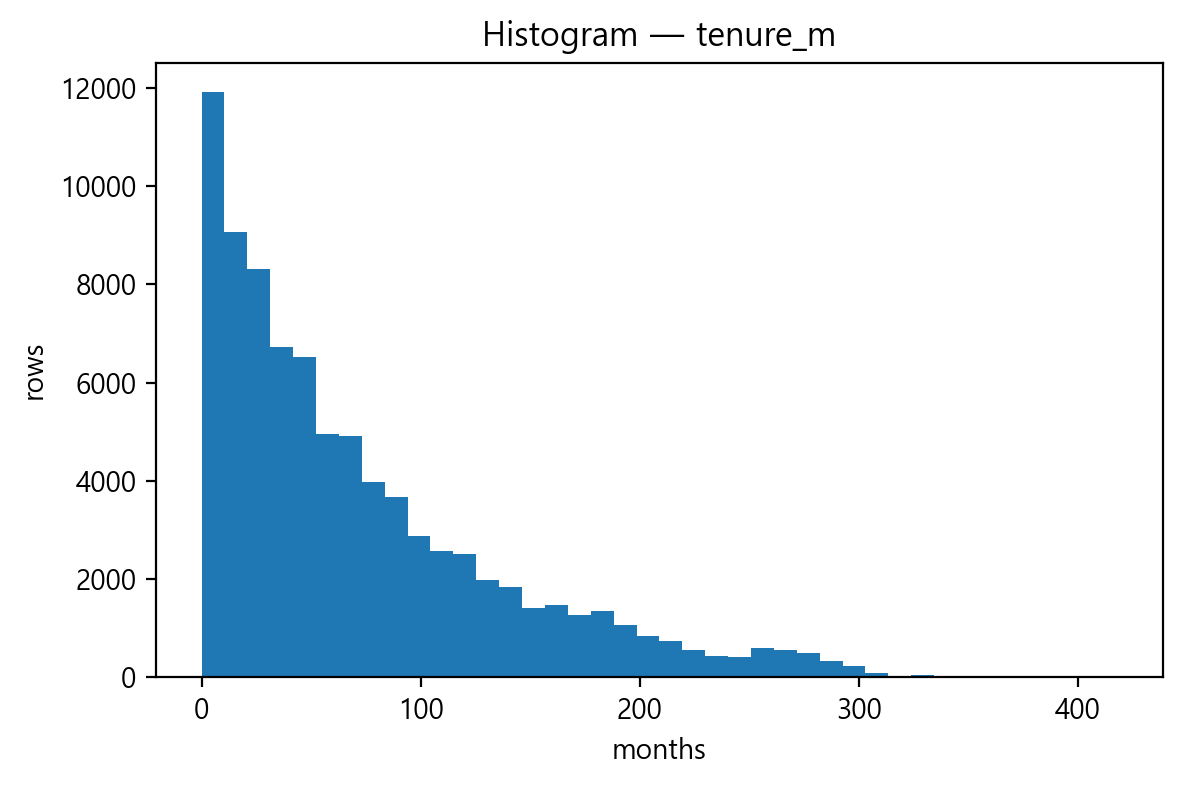

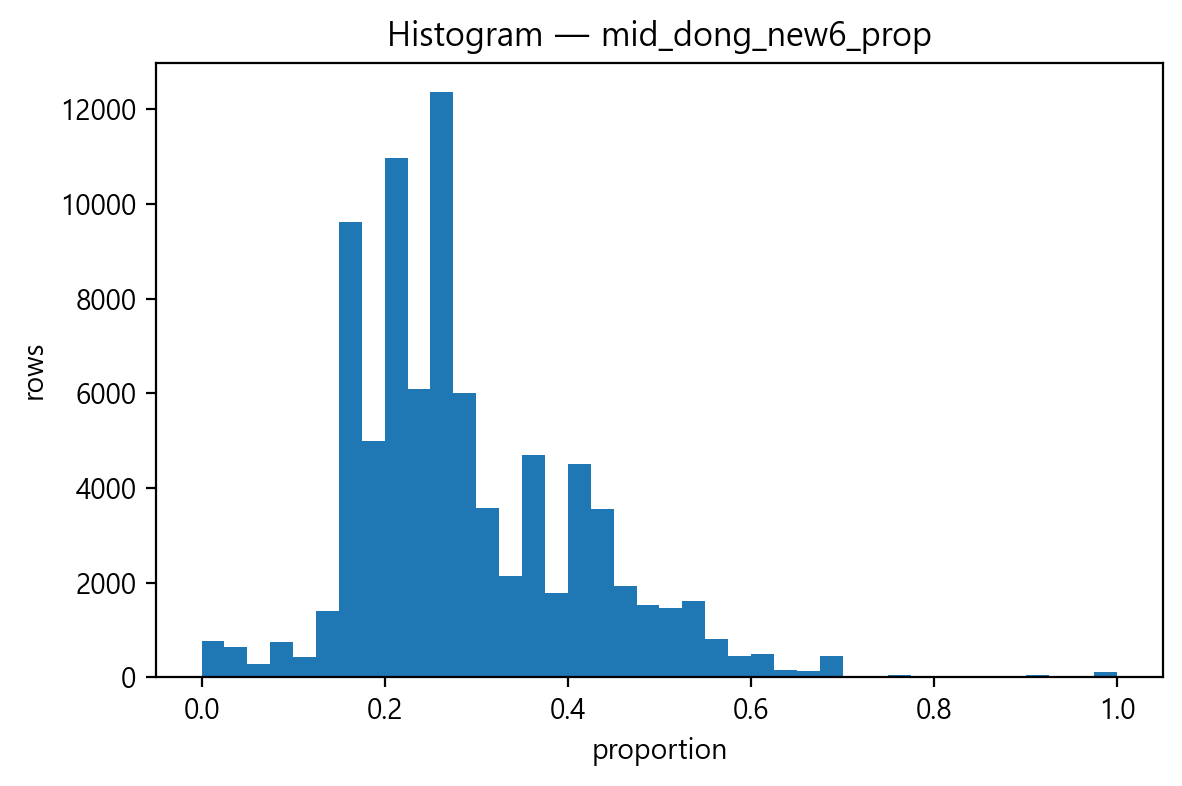

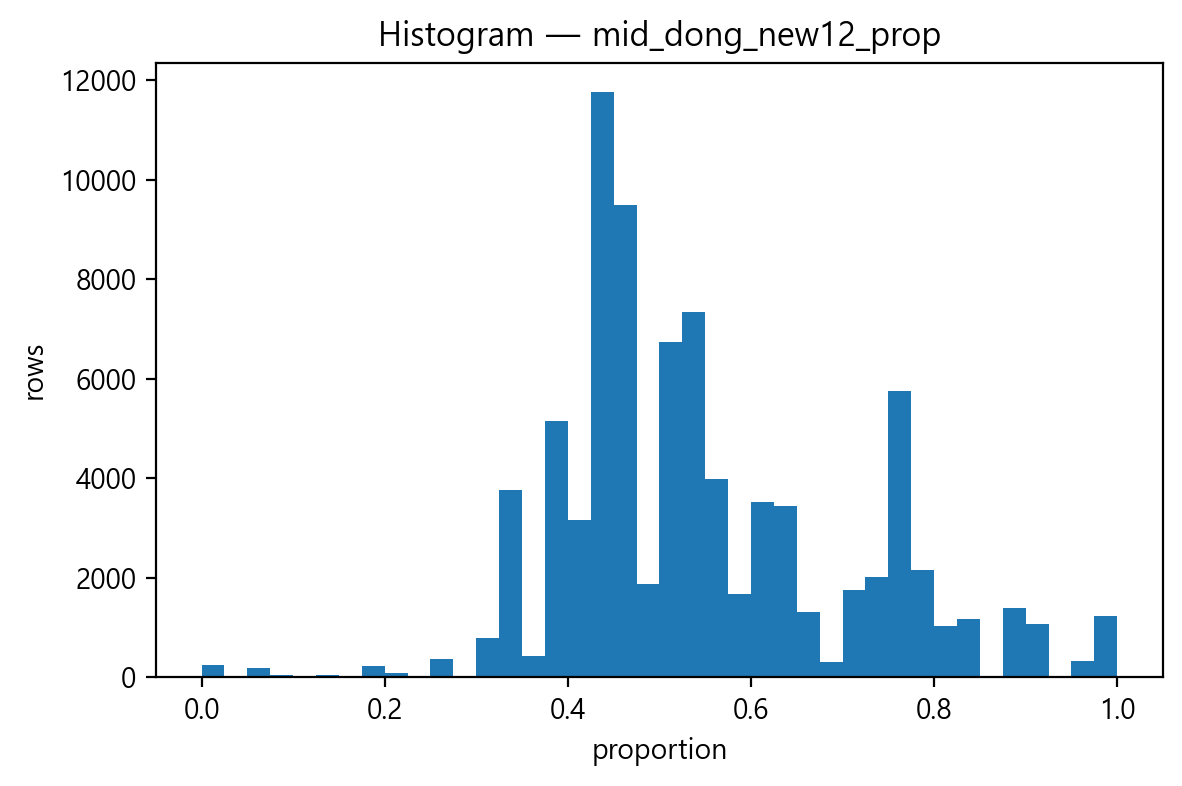

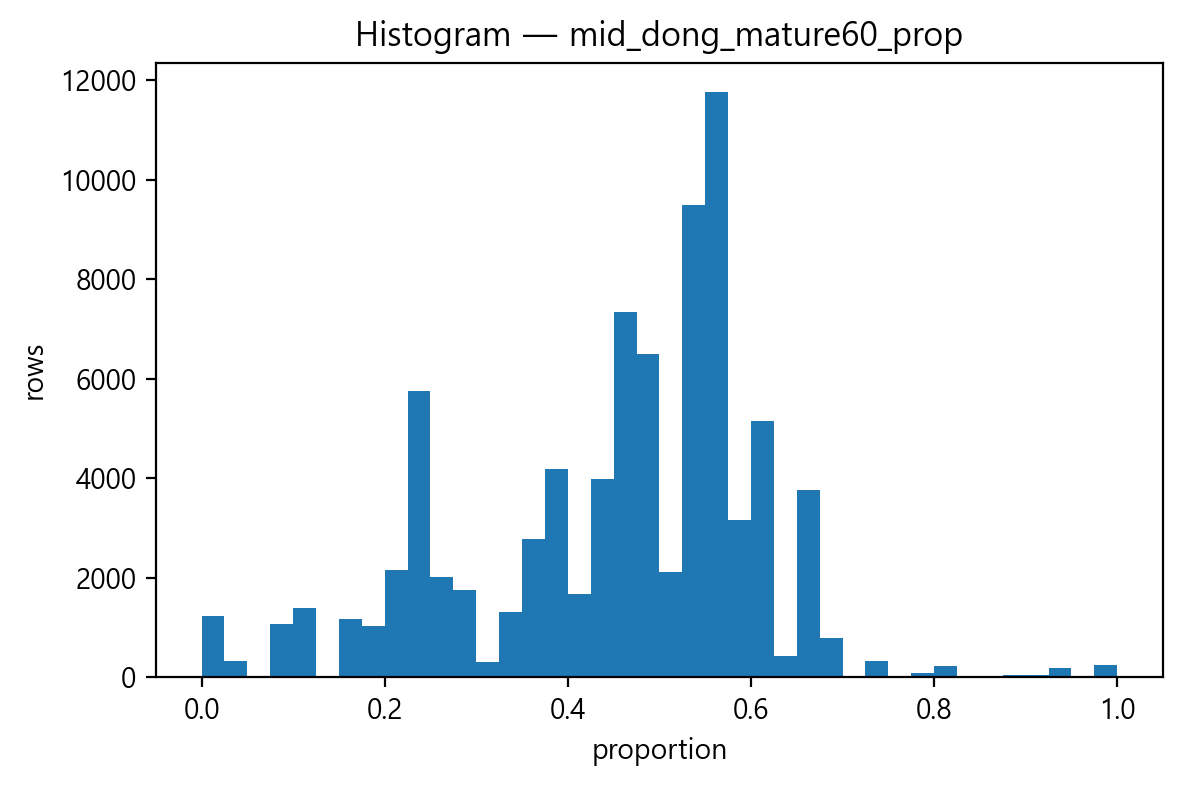

In [ ]:
# 생애주기 구성(운영기간 기반)
#  mid_dong_new12_prop: 같은 업종×행정동 내에서 운영 12개월 이내 점포 비중
#  mid_dong_new12_prop: 12개월 이내 비중
#  mid_dong_mature60_prop: 60개월 이상 비중

t = pd.to_numeric(df["tenure_m"], errors="coerce")
df["_flag_new12"]  = (t <= 12).astype(float)
df["_flag_new36"]  = (t <= 36).astype(float)
df["_flag_new60"]  = (t <= 60).astype(float)
df["_flag_mat60"]  = (t >  60).astype(float)

df["mid_dong_new6_prop"]    = df.groupby(["업종중분류","행정동"])["_flag_new6"].transform("mean")
df["mid_dong_new12_prop"]   = df.groupby(["업종중분류","행정동"])["_flag_new12"].transform("mean")
df["mid_dong_mature60_prop"]= df.groupby(["업종중분류","행정동"])["_flag_mat60"].transform("mean")

df.drop(columns=["_flag_new6","_flag_new12","_flag_mat60"], inplace=True)

# tenure_m 히스토그램 (분포를 먼저 확인)
plt.figure(figsize=(6,4))
plt.hist(pd.to_numeric(df["tenure_m"], errors="coerce").dropna(), bins=40)
plt.title("Histogram — tenure_m"); plt.xlabel("months"); plt.ylabel("rows")
plt.tight_layout(); plt.show()

# 생애주기 비중 히스토그램
for c in ["mid_dong_new6_prop","mid_dong_new12_prop","mid_dong_mature60_prop"]:
    if c in df.columns:
        plt.figure(figsize=(6,4))
        plt.hist(pd.to_numeric(df[c], errors="coerce").dropna(), bins=40)
        plt.title(f"Histogram — {c}"); plt.xlabel("proportion"); plt.ylabel("rows")
        plt.tight_layout(); plt.show()

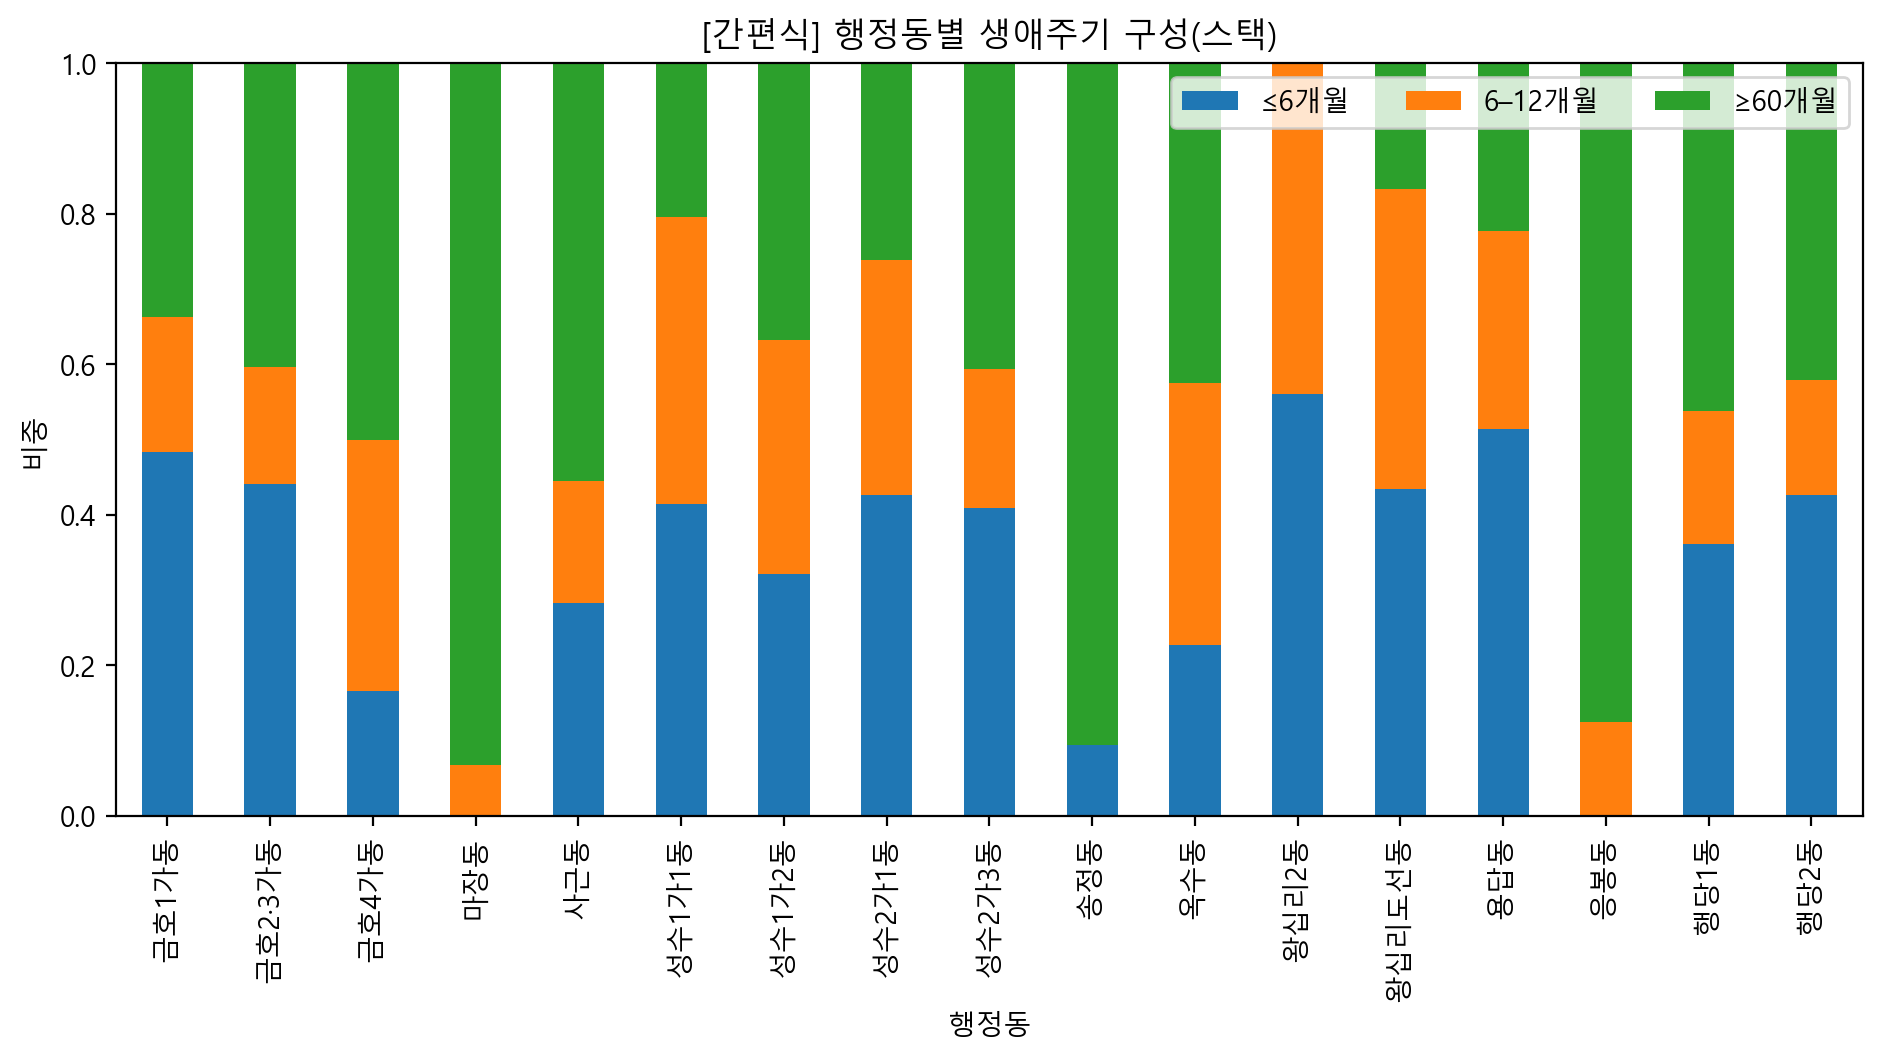

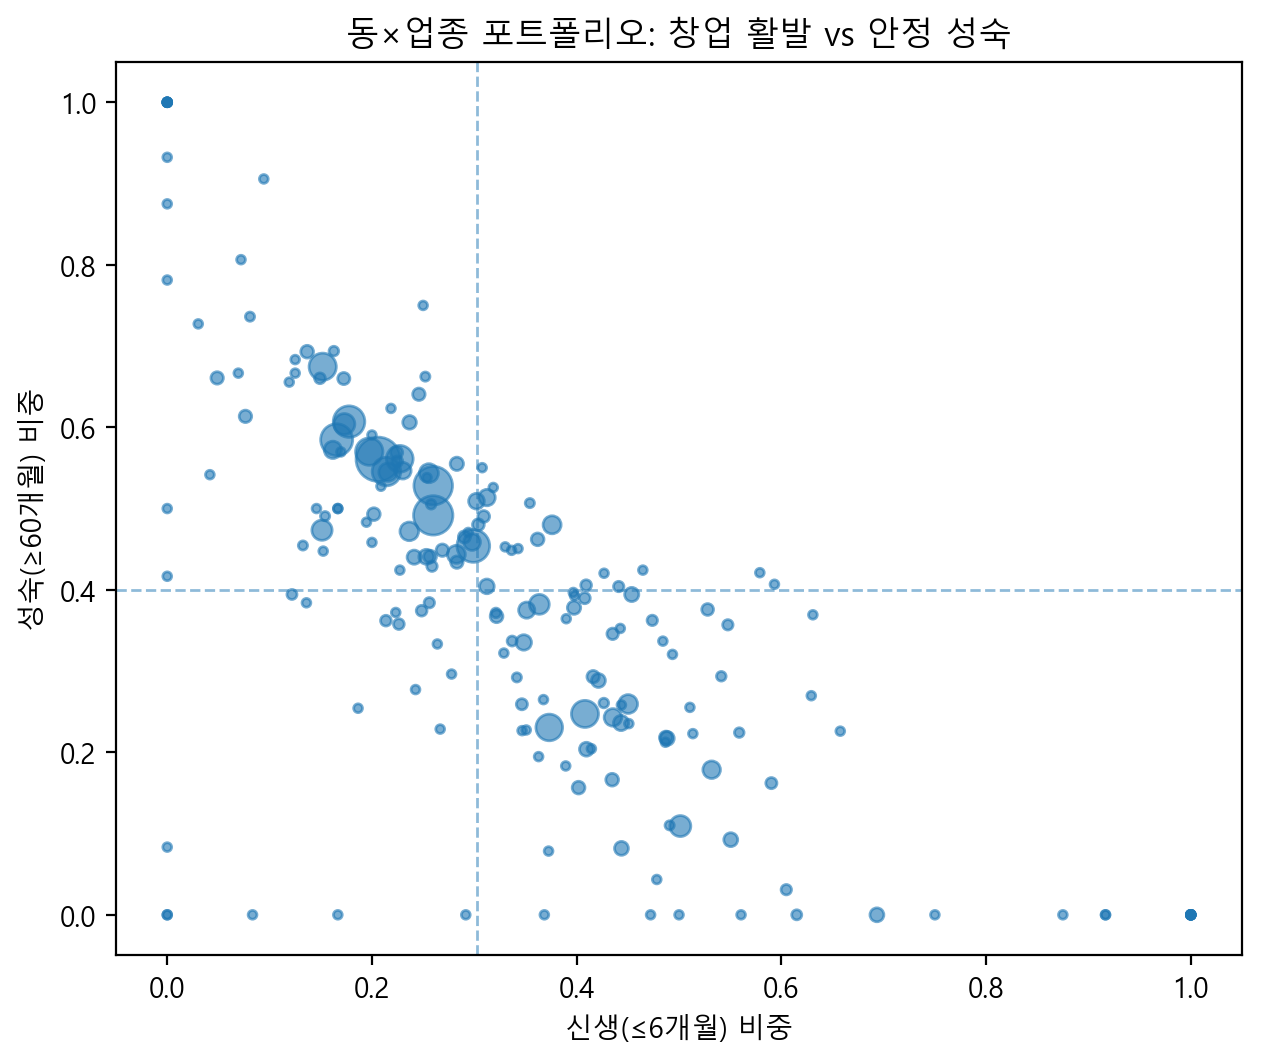

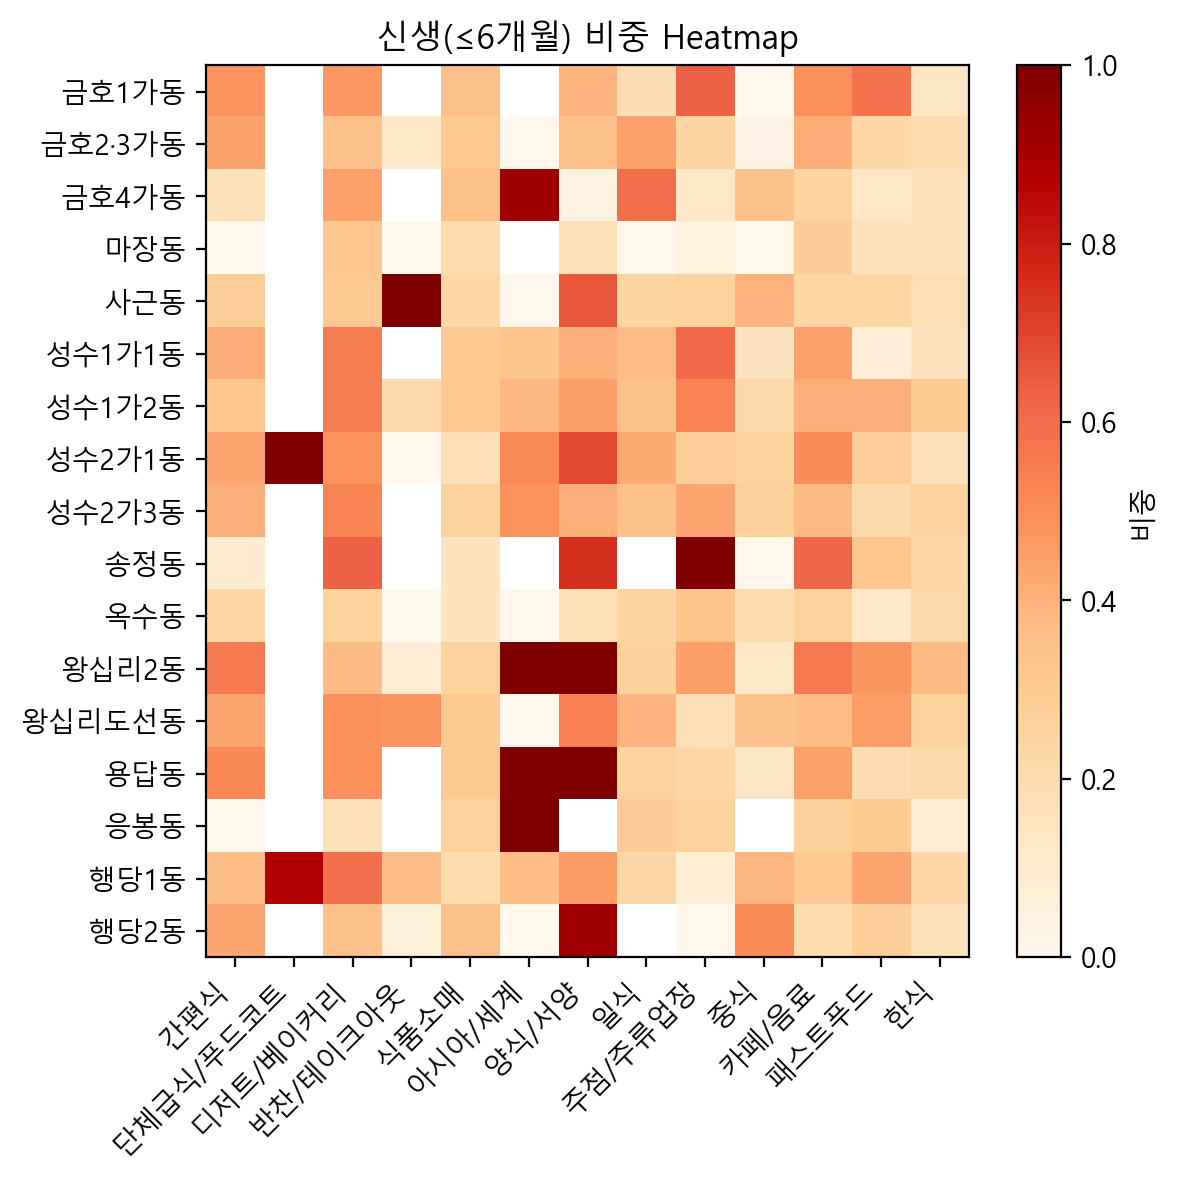

지도 저장: seongdong_lifecycle_markers.html


In [ ]:
# import os, io, json, base64
# import numpy as np
# import pandas as pd
# import matplotlib as mpl
# mpl.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["AppleGothic","Malgun Gothic","NanumGothic","Noto Sans CJK KR","DejaVu Sans"],
#     "axes.unicode_minus": False,
# })
# import matplotlib.pyplot as plt

# # ───────── 0) 생애주기 요약 테이블 준비 ─────────
# # 이미 비중 컬럼이 있다면 그걸 사용, 없다면 tenure_m로 계산해도 됨(주석 참고)
# need_cols = ["행정동","업종중분류","가맹점번호",
#              "mid_dong_new6_prop","mid_dong_new12_prop","mid_dong_mature60_prop"]
# missing = [c for c in need_cols if c not in df.columns]
# if missing:
#     raise ValueError(f"필수 컬럼이 없습니다: {missing}")

# # (동×업종) 단위로 비중 평균/가중평균 중 선택
# # 점포 수로 가중평균을 쓰려면 아래 w_avg 사용 (여기선 단순 평균으로도 충분)
# grp = (df
#        .groupby(["행정동","업종중분류"], as_index=False)
#        [["mid_dong_new6_prop","mid_dong_new12_prop","mid_dong_mature60_prop"]].mean())
# # 보조 정보: (동×업종) 점포 수
# cnt = df.groupby(["행정동","업종중분류"])["가맹점번호"].nunique().reset_index(name="store_n")
# life = pd.merge(grp, cnt, on=["행정동","업종중분류"], how="left")

# # 동 전체 지표(업종 혼합)도 만들기(점포 수로 가중평균)
# life_dong = (life
#              .groupby("행정동")
#              .apply(lambda g: pd.Series({
#                  "new6": np.average(g["mid_dong_new6_prop"],  weights=g["store_n"]),
#                  "new12":np.average(g["mid_dong_new12_prop"], weights=g["store_n"]),
#                  "m60":  np.average(g["mid_dong_mature60_prop"], weights=g["store_n"]),
#                  "store_n_total": g["store_n"].sum()
#              }))
#              .reset_index())

# # ───────── 1) 동별 스택 막대 (업종 선택 가능) ─────────
# target_mid = sorted(life["업종중분류"].unique().tolist())[0]  # ← 기본 업종(원하면 바꿔서 반복)
# tmp = life[life["업종중분류"]==target_mid].copy().sort_values("행정동")
# comp = pd.DataFrame({
#     "행정동": tmp["행정동"],
#     "≤6개월": tmp["mid_dong_new6_prop"],
#     "6–12개월": (tmp["mid_dong_new12_prop"] - tmp["mid_dong_new6_prop"]).clip(lower=0),
#     "≥60개월": tmp["mid_dong_mature60_prop"]
# }).set_index("행정동")

# fig, ax = plt.subplots(figsize=(9.5,5.4))
# comp.plot(kind="bar", stacked=True, ax=ax)
# ax.set_ylim(0,1); ax.set_ylabel("비중"); ax.set_title(f"[{target_mid}] 행정동별 생애주기 구성(스택)")
# ax.legend(loc="upper right", ncol=3)
# plt.tight_layout(); plt.show()

# # ───────── 2) Scatter: 신생 vs 성숙 (버블=점포수) ─────────
# fig, ax = plt.subplots(figsize=(6.4,5.4))
# ax.scatter(life["mid_dong_new6_prop"], life["mid_dong_mature60_prop"],
#            s=life["store_n"].clip(10, 400), alpha=0.6)
# ax.set_xlabel("신생(≤6개월) 비중"); ax.set_ylabel("성숙(≥60개월) 비중")
# ax.set_title("동×업종 포트폴리오: 창업 활발 vs 안정 성숙")
# # 참고선(중앙값)
# ax.axvline(life["mid_dong_new6_prop"].median(), ls="--", lw=1, alpha=0.5)
# ax.axylin = ax.axhline(life["mid_dong_mature60_prop"].median(), ls="--", lw=1, alpha=0.5)
# plt.tight_layout(); plt.show()

# # ───────── 3) Heatmap: 행정동×업종 신생(≤6) 비중 ─────────
# hm = life.pivot(index="행정동", columns="업종중분류", values="mid_dong_new6_prop")
# fig, ax = plt.subplots(figsize=(max(6,hm.shape[1]*0.4), max(6,hm.shape[0]*0.35)))
# im = ax.imshow(hm.values, aspect="auto", cmap="OrRd", vmin=0, vmax=hm.max().max())
# ax.set_xticks(range(hm.shape[1])); ax.set_xticklabels(hm.columns, rotation=45, ha="right")
# ax.set_yticks(range(hm.shape[0])); ax.set_yticklabels(hm.index)
# ax.set_title("신생(≤6개월) 비중 Heatmap"); fig.colorbar(im, ax=ax, label="비중")
# plt.tight_layout(); plt.show()

# # ───────── 4) (선택) 지도: 동 중심점에 마커(신생/성숙 토글) ─────────
# try:
#     import folium
#     from folium import GeoJson
#     from branca.element import Element, MacroElement, Template

#     # 4-1) 동 중심점(GeoJSON에서 대충 중심값 계산) -------------------
#     GJ_PATH = "./data/administrative_district/4_서울시_행정동/서울_행정동_경계_2017.geojson"
#     with open(GJ_PATH, "r", encoding="utf-8") as f:
#         gj = json.load(f)

#     # '서울특별시 성동구 {동}' 매칭
#     dong_full = set("서울특별시 성동구 " + life_dong["행정동"])
#     feats = [ft for ft in gj["features"]
#              if any(str(v) in dong_full for v in ft.get("properties",{}).values())]

#     def poly_centroid(coords):
#         # 중첩배열에서 모든 좌표를 평탄화 후 평균(간이)
#         pts=[]
#         def rec(a):
#             if isinstance(a[0], (int,float)): pts.append((a[1],a[0]))
#             else:
#                 for x in a: rec(x)
#         rec(coords)
#         arr = np.array(pts)
#         return float(arr[:,0].mean()), float(arr[:,1].mean())

#     centers = {}
#     for ft in feats:
#         name = None
#         for v in ft["properties"].values():
#             if isinstance(v,str) and v.startswith("서울특별시 성동구 "):
#                 name = v.replace("서울특별시 성동구 ","")
#         if not name: continue
#         lat, lon = poly_centroid(ft["geometry"]["coordinates"])
#         centers[name] = (lat, lon)

#     life_dong["lat"] = life_dong["행정동"].map(lambda d: centers.get(d,(np.nan,np.nan))[0])
#     life_dong["lon"] = life_dong["행정동"].map(lambda d: centers.get(d,(np.nan,np.nan))[1])
#     life_dong_valid = life_dong.dropna(subset=["lat","lon"]).copy()

#     # 4-2) 지도 생성 & 토글 -------------------------------------------
#     if not life_dong_valid.empty:
#         lat0, lon0 = life_dong_valid["lat"].mean(), life_dong_valid["lon"].mean()
#         m = folium.Map(location=[lat0,lon0], zoom_start=13, tiles="CartoDB positron")

#         # 경계 그리기
#         def style(_): return {"fillColor":"#fffff0","fillOpacity":0.15,"color":"#333","weight":1.5}
#         GeoJson({"type":"FeatureCollection","features":feats}, style_function=style).add_to(m)

#         # 동별 마커 레이어 두 개: 신생/성숙
#         new_layer = folium.FeatureGroup(name="신생(≤6개월) 비중", show=True)
#         mat_layer = folium.FeatureGroup(name="성숙(≥60개월) 비중", show=False)

#         for _, r in life_dong_valid.iterrows():
#             # 신생
#             folium.CircleMarker(
#                 [r["lat"], r["lon"]],
#                 radius = 6 + 10 * float(r["new6"]),  # 비중 기반 크기
#                 color  = "#d7301f", fill=True, fill_opacity=0.6, weight=1,
#                 popup  = folium.Popup(f'{r["행정동"]}<br>신생≤6: {r["new6"]*100:.1f}%<br>성숙≥60: {r["m60"]*100:.1f}%', max_width=200)
#             ).add_to(new_layer)

#             # 성숙
#             folium.CircleMarker(
#                 [r["lat"], r["lon"]],
#                 radius = 6 + 10 * float(r["m60"]),
#                 color  = "#08519c", fill=True, fill_opacity=0.6, weight=1,
#                 popup  = folium.Popup(f'{r["행정동"]}<br>성숙≥60: {r["m60"]*100:.1f}%<br>신생≤6: {r["new6"]*100:.1f}%', max_width=200)
#             ).add_to(mat_layer)

#         new_layer.add_to(m); mat_layer.add_to(m)
#         folium.LayerControl(collapsed=False).add_to(m)

#         OUT_HTML = "seongdong_lifecycle_markers.html"
#         m.save(OUT_HTML)
#         print("지도 저장:", OUT_HTML)
#     else:
#         print("지도: 중심점 계산에 실패했거나 life_dong이 비어 있습니다.")

# except Exception as e:
#     print("지도 생성 중 오류(생략 가능):", e)


[창 기준] close | 최근창: 2025-03 ~ 2025-08
[고유 가맹점] 최근 폐업수 / 전체 폐업수: 90 / 123


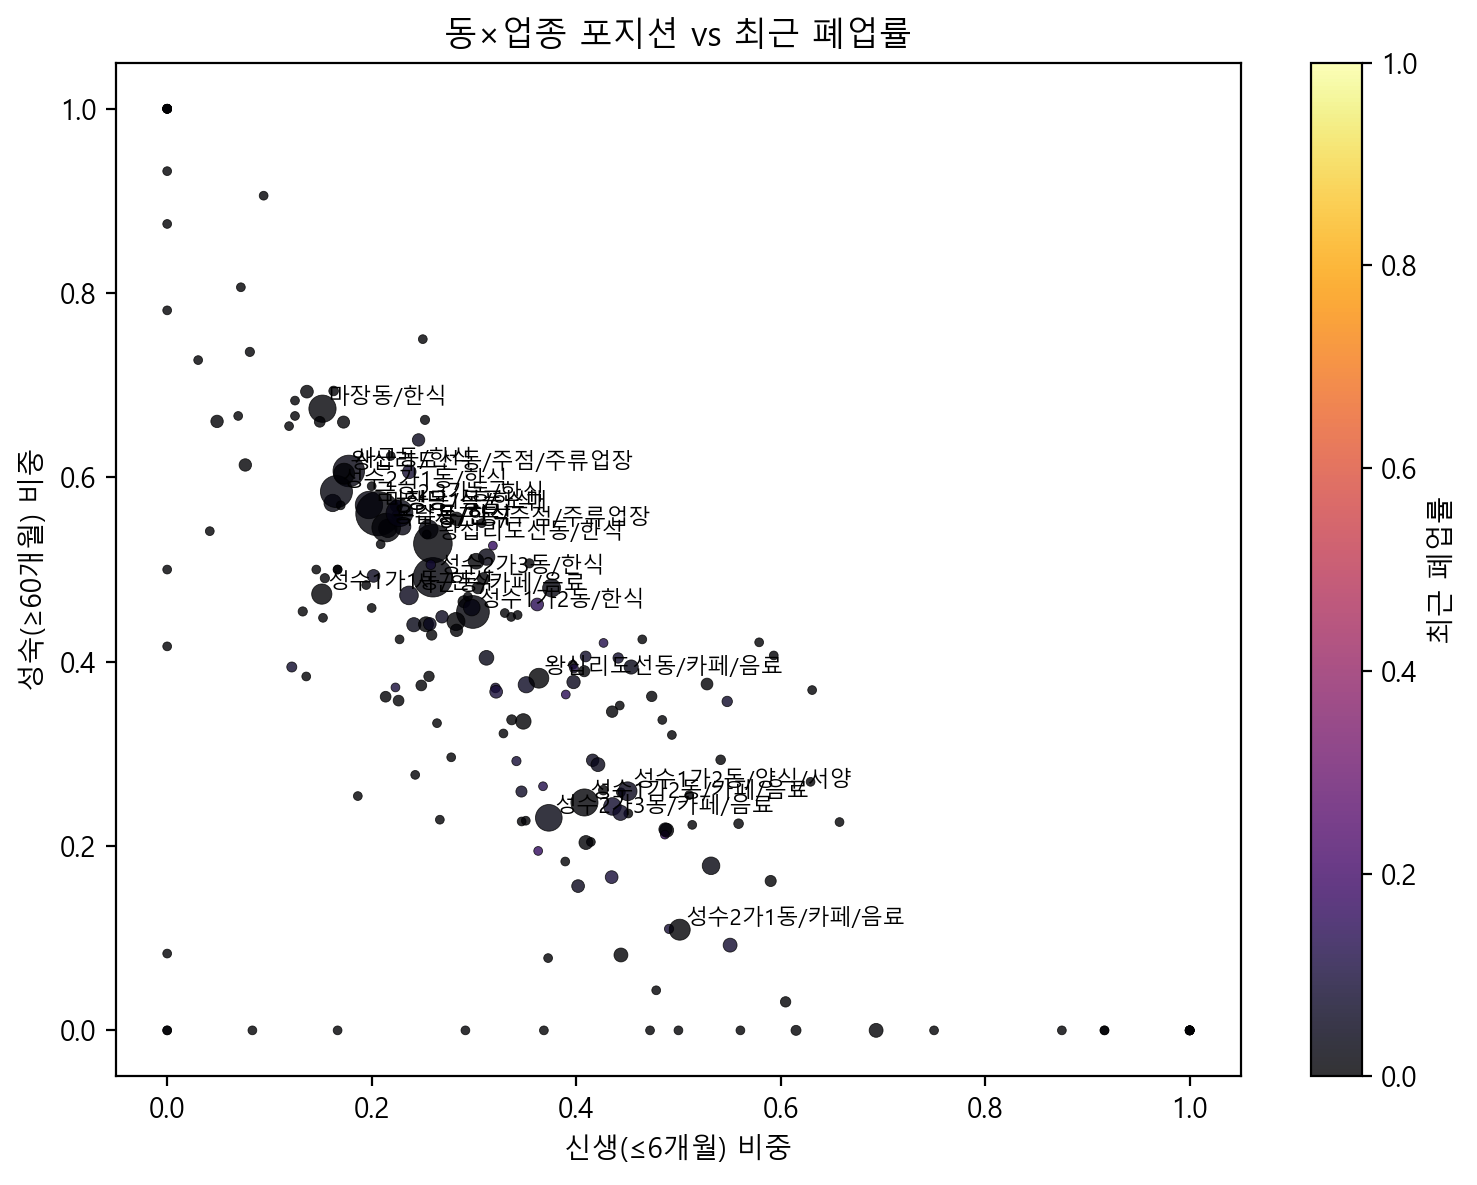

TypeError: Image data of dtype object cannot be converted to float

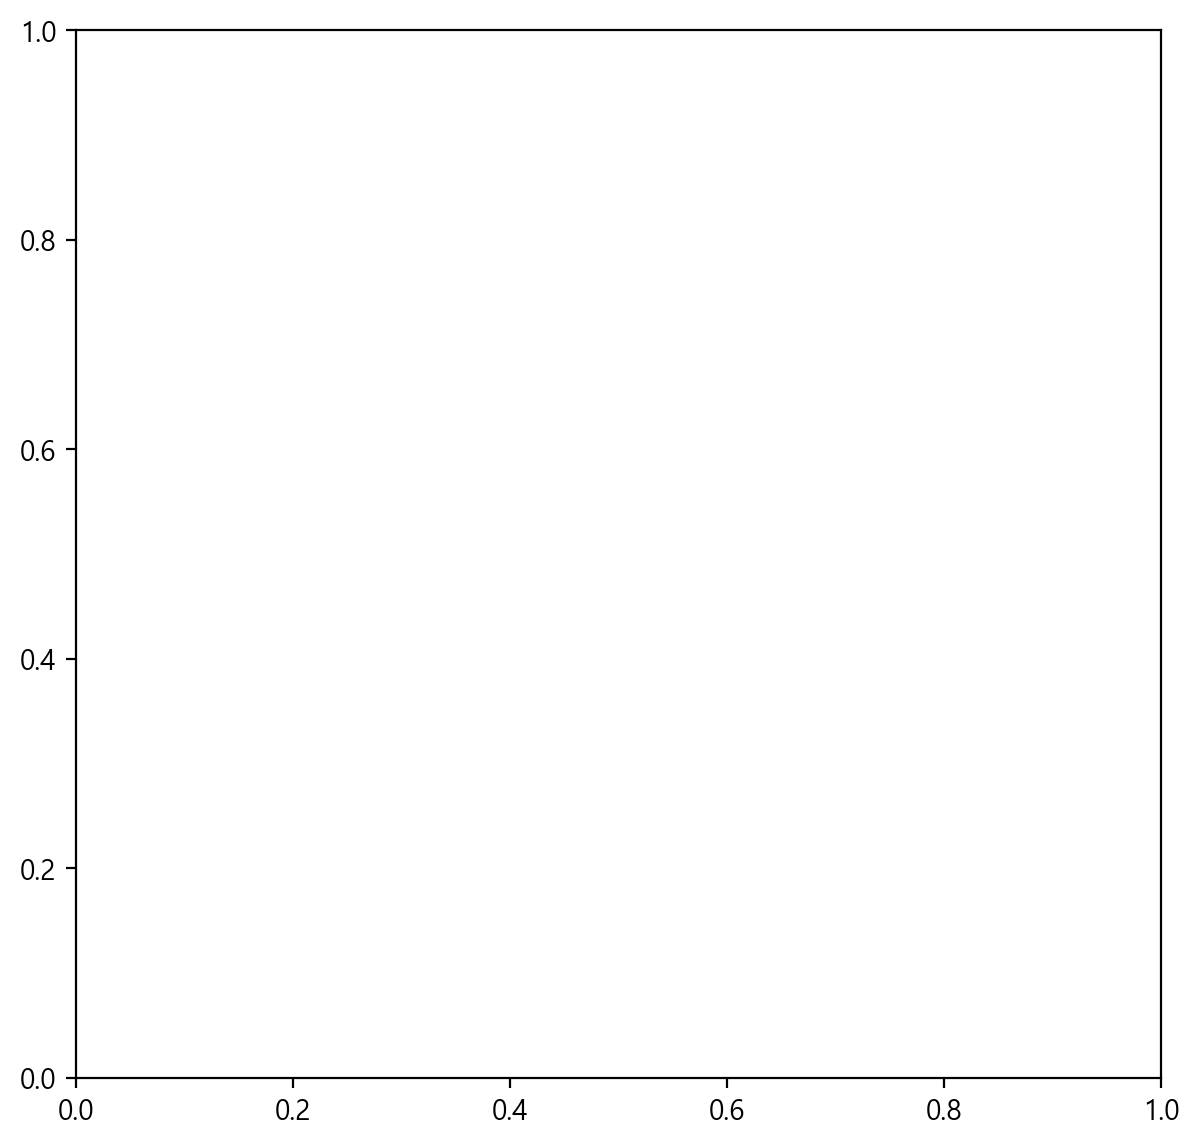

In [ ]:
# import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt

# # 한글 폰트
# mpl.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["AppleGothic","Malgun Gothic","NanumGothic","Noto Sans CJK KR","DejaVu Sans"],
#     "axes.unicode_minus": False,
# })

# # ========= 0) 안전 파싱 & 스토어 스냅샷(동/업종 귀속), 폐업월 =========
# df = df.copy()
# df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
# df["close_dt"] = pd.to_datetime(df["close_dt"], errors="coerce")

# # 스토어 스냅샷(가장 최신 dt 행) → 동/업종 귀속, 생애주기 지표
# idx_latest = (df.sort_values(["가맹점번호","dt"])
#                 .groupby("가맹점번호", as_index=False)
#                 .tail(1).index)
# store_snap = df.loc[idx_latest, ["가맹점번호","행정동","업종중분류",
#                                  "mid_dong_new6_prop","mid_dong_new12_prop","mid_dong_mature60_prop"]].copy()

# # 스토어별 최종 폐업일 (가맹점 단위 1회 집계)
# store_close = (df.groupby("가맹점번호", dropna=False)["close_dt"].max()
#                  .rename("close_dt_max"))

# # ========= 1) '최근 N개월' 기준 선택 =========
# #  - 'close' : 폐업일의 최신월을 기준(권장, "최근 X개월 폐업" 의미와 일치)
# #  - 'today' : 오늘 기준
# #  - 'dt'    : 기준년월의 최신월 기준(이전 방식)
# RECENT_ANCHOR = "close"
# N_RECENT = 6

# def to_month_period(ts):
#     if pd.isna(ts): return pd.NaT
#     return pd.Period(f"{ts.year}-{ts.month:02d}", "M")

# if RECENT_ANCHOR == "close":
#     anchor_ts = pd.to_datetime(store_close.max(), errors="coerce")
#     if pd.isna(anchor_ts):
#         anchor_ts = pd.to_datetime(df["dt"].max(), errors="coerce")
# elif RECENT_ANCHOR == "today":
#     anchor_ts = pd.Timestamp.today().normalize()
# else:
#     anchor_ts = pd.to_datetime(df["dt"].max(), errors="coerce")

# anchorM = to_month_period(anchor_ts)
# startM  = anchorM - (N_RECENT-1)

# # 스토어별 최종 폐업 '월'
# store_closeM = store_close.dropna().map(to_month_period)

# # 폐업 플래그(가맹점 단위)
# store_flag_recent = store_closeM.between(startM, anchorM).astype("Int8")
# store_flag_any    = store_closeM.notna().astype("Int8")

# # 스냅샷에 조인
# store_dim = (store_snap
#              .merge(store_flag_recent.rename("closed_recent"), left_on="가맹점번호", right_index=True, how="left")
#              .merge(store_flag_any.rename("closed_any"),     left_on="가맹점번호", right_index=True, how="left"))
# store_dim[["closed_recent","closed_any"]] = store_dim[["closed_recent","closed_any"]].fillna(0).astype("Int8")

# print(f"[창 기준] {RECENT_ANCHOR} | 최근창: {startM} ~ {anchorM}")
# print("[고유 가맹점] 최근 폐업수 / 전체 폐업수:", int(store_dim["closed_recent"].sum()), "/", int(store_dim["closed_any"].sum()))

# # ========= 2) 동×업종 집계: 점포수, 폐업률(최근/전체), 생애주기 평균 =========
# agg = (store_dim
#        .groupby(["행정동","업종중분류"], as_index=False)
#        .agg(store_n = ("가맹점번호","nunique"),
#             close_rate_recent = ("closed_recent","mean"),
#             close_rate_any    = ("closed_any","mean"),
#             new6  = ("mid_dong_new6_prop","mean"),
#             new12 = ("mid_dong_new12_prop","mean"),
#             m60   = ("mid_dong_mature60_prop","mean"))
#       )

# # 동 전체(업종 가중) 폐업률
# dong_rollup = (agg
#                .groupby("행정동")
#                .apply(lambda g: pd.Series({
#                    "store_n_total": g["store_n"].sum(),
#                    "close_recent":  np.average(g["close_rate_recent"], weights=g["store_n"]),
#                    "close_any":     np.average(g["close_rate_any"],    weights=g["store_n"]),
#                    "new6":          np.average(g["new6"],              weights=g["store_n"]),
#                    "m60":           np.average(g["m60"],               weights=g["store_n"]),
#                }))
#                .reset_index())

# # ========= 3) 시각화 =========
# # -- #1 포지션 스캐터: x=신생(≤6), y=성숙(≥60), 색=최근 폐업률, 크기=점포수 --
# fig, ax = plt.subplots(figsize=(7.8,6.0))
# sc = ax.scatter(agg["new6"], agg["m60"],
#                 s = agg["store_n"].clip(10, 400),
#                 c = agg["close_rate_recent"],
#                 cmap="inferno", vmin=0, vmax=max(0.01, agg["close_rate_recent"].max()),
#                 alpha=0.8, edgecolor="k", linewidth=0.3)
# ax.set_xlabel("신생(≤6개월) 비중")
# ax.set_ylabel("성숙(≥60개월) 비중")
# ax.set_title("동×업종 포지션 vs 최근 폐업률")
# cb = plt.colorbar(sc, ax=ax); cb.set_label("최근 폐업률")
# for i, r in agg.iterrows():
#     if r["store_n"] >= agg["store_n"].quantile(0.9):  # 점포수 상위만 라벨
#         ax.text(r["new6"]+0.005, r["m60"]+0.005, f'{r["행정동"]}/{r["업종중분류"]}', fontsize=8)
# plt.tight_layout(); plt.show()

# # -- #2 히트맵: (행정동 × 업종) 최근 폐업률 --
# hm = agg.pivot(index="행정동", columns="업종중분류", values="close_rate_recent").sort_index()
# fig, ax = plt.subplots(figsize=(max(7, hm.shape[1]*0.45), max(6, hm.shape[0]*0.4)))
# im = ax.imshow(hm.values, aspect="auto", cmap="Reds", vmin=0, vmax=max(0.01, hm.max().max()))
# ax.set_xticks(range(hm.shape[1])); ax.set_xticklabels(hm.columns, rotation=45, ha="right")
# ax.set_yticks(range(hm.shape[0])); ax.set_yticklabels(hm.index)
# ax.set_title("최근 폐업률 히트맵 (행정동 × 업종)")
# fig.colorbar(im, ax=ax, label="최근 폐업률")
# plt.tight_layout(); plt.show()

# # -- #3 동 롤업 바차트: 최근 vs 전체 폐업률 --
# dong_sorted = dong_rollup.sort_values("close_recent", ascending=False)
# fig, ax = plt.subplots(figsize=(9.5,5.4))
# x = np.arange(len(dong_sorted))
# w = 0.38
# ax.bar(x - w/2, dong_sorted["close_recent"]*100, width=w, label="최근", alpha=0.85)
# ax.bar(x + w/2, dong_sorted["close_any"]*100,    width=w, label="전체", alpha=0.65)
# ax.set_xticks(x); ax.set_xticklabels(dong_sorted["행정동"], rotation=45, ha="right")
# ax.set_ylabel("폐업률(%)"); ax.set_title("행정동별 폐업률: 최근 vs 전체 (업종 가중)")
# ax.legend()
# plt.tight_layout(); plt.show()


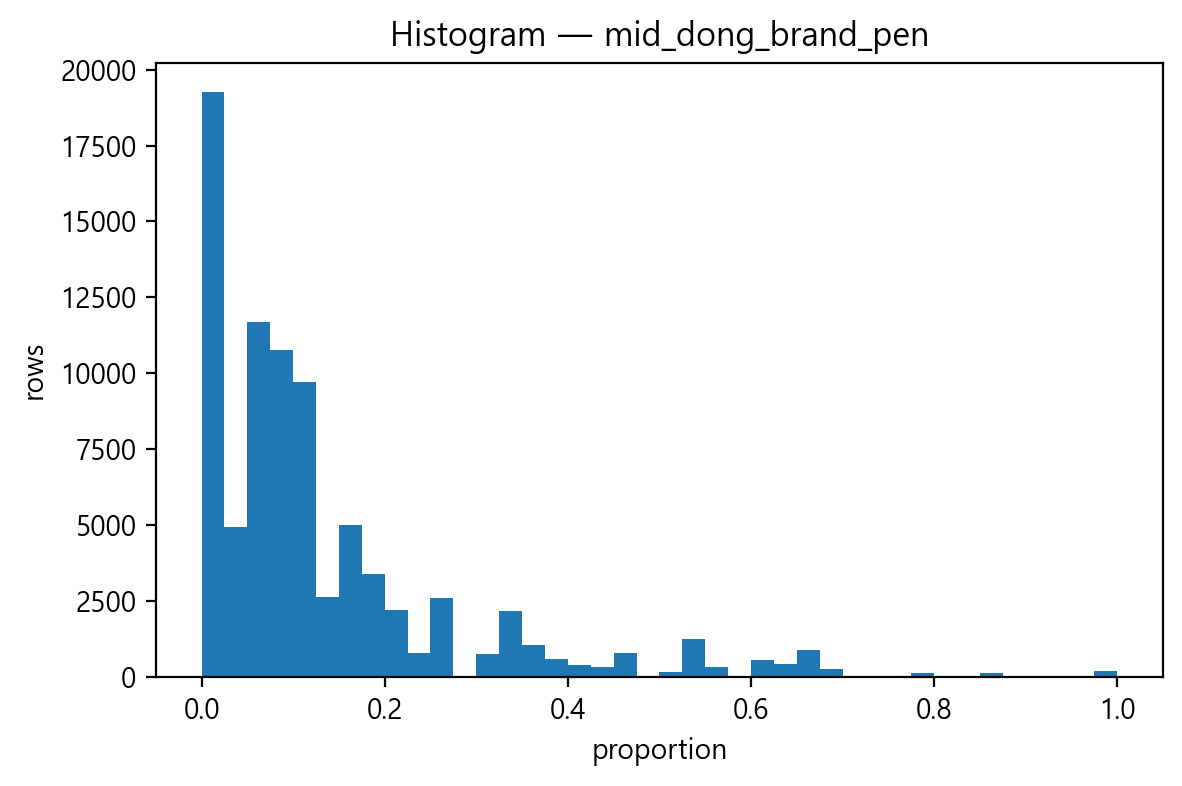

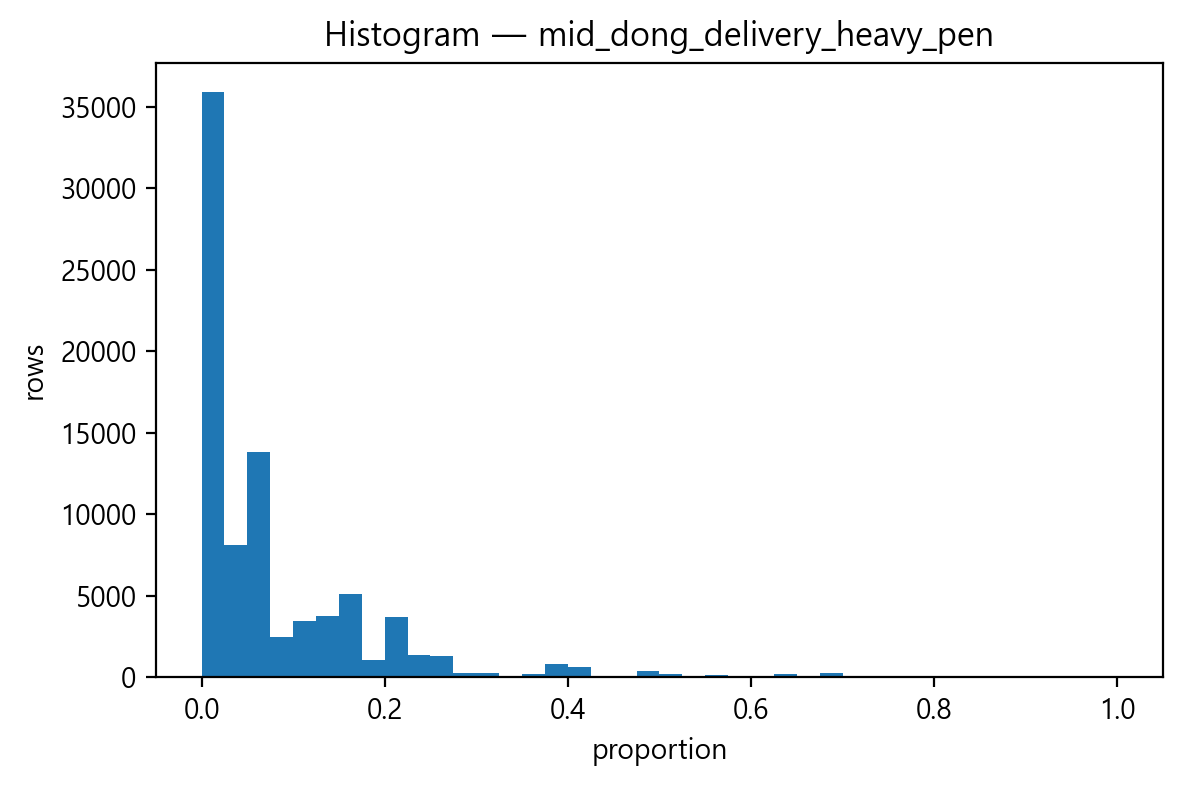

In [ ]:
# # 채널/브랜드 침투도
# #  is_brand: 브랜드 코드 존재(=체인) 여부
# #  mid_dong_brand_pen: 같은 업종×행정동 내 브랜드 점포 비중
# #  delivery_heavy: 배달 비중 50% 이상 여부
# #  mid_dong_delivery_heavy_pen: 배달 비중 50% 이상 비중

# df["is_brand"] = (~df["브랜드코드"].isna()).astype("Int8")
# df["mid_dong_brand_pen"] = df.groupby(["업종중분류","행정동"])["is_brand"].transform("mean")

# v = pd.to_numeric(df["배달매출금액 비율"], errors="coerce")
# if "delivery_heavy" not in df.columns:
#     df["delivery_heavy"] = (v >= 50).astype("Int8")
# df["mid_dong_delivery_heavy_pen"] = df.groupby(["업종중분류","행정동"])["delivery_heavy"].transform("mean")
# df["mid_dong_delivery_ratio_mean"] = df.groupby(["업종중분류","행정동"])["배달매출금액 비율"].transform("mean")

# # mid_dong_brand_pen 히스토그램
# plt.figure(figsize=(6,4))
# plt.hist(pd.to_numeric(df["mid_dong_brand_pen"], errors="coerce").dropna(), bins=40)
# plt.title("Histogram — mid_dong_brand_pen"); plt.xlabel("proportion"); plt.ylabel("rows")
# plt.tight_layout(); plt.show()

# # mid_dong_delivery_heavy_pen 히스토그램
# plt.figure(figsize=(6,4))
# plt.hist(pd.to_numeric(df["mid_dong_delivery_heavy_pen"], errors="coerce").dropna(), bins=40)
# plt.title("Histogram — mid_dong_delivery_heavy_pen"); plt.xlabel("proportion"); plt.ylabel("rows")
# plt.tight_layout(); plt.show()

In [ ]:
# # 경쟁 밀도(반경 300m 내 점포 수)
# #  near_all_300m: 반경 300m 내 존재하는 모든 점포 수(자기 자신 제외)
# #  near_same_mid_300m: 반경 300m 내 동일 업종중분류(industry_mid) 점포 수
# #  near_same_to_all: 300m 내 전체 점포 중 동일 업종이 차지하는 비율
# #  mid_dong_near_all_300m_mean
# #  mid_dong_near_same_mid_300m_mean
# #  mid_dong_near_same_to_all_mean: 같은 업종×행정동 내부에서 근접 경쟁 지표의 평균

# RADIUS_M = 300                           # 반경(m)
# EARTH_R = 6371.0                         # km
# RAD = np.deg2rad
# RADIUS_RAD = (RADIUS_M / 1000) / EARTH_R # 라디안 반경

# # 월별 스냅샷: (dt, 가맹점번호) 중복 제거 → 점포당 월 1행만
# df2 = df.dropna(subset=["위도","경도"]).copy()
# snap = (df2.sort_values(["dt","가맹점번호"]).drop_duplicates(["dt","가맹점번호"])
#             [["dt","가맹점번호","업종중분류","위도","경도"]].reset_index(drop=True))

# snap["near_all_300m"] = 0
# snap["near_same_mid_300m"] = 0

# # 월별로 BallTree로 반경 이웃 계산 
# for (t,), sub in snap.groupby(["dt"], dropna=False):
#     idx = sub.index
#     XY = np.c_[RAD(sub["위도"].to_numpy()), RAD(sub["경도"].to_numpy())]  # 라디안
#     mids = sub["업종중분류"].to_numpy()

#     if len(sub) == 1:
#         # 이 달에 점포가 1곳뿐이면 모두 0
#         snap.loc[idx, ["near_all_300m","near_same_mid_300m"]] = 0
#         continue

#     tree = BallTree(XY, metric="haversine")
#     neigh = tree.query_radius(XY, r=RADIUS_RAD, return_distance=False)  # 각 점포의 이웃 인덱스(자기 포함)

#     all_counts  = np.fromiter((len(ix) - 1 for ix in neigh), dtype=int)                      # 자기 제외
#     same_counts = np.fromiter(((mids[i] == mids[ix]).sum() - 1 for i, ix in enumerate(neigh)), dtype=int)

#     snap.loc[idx, "near_all_300m"] = all_counts
#     snap.loc[idx, "near_same_mid_300m"] = same_counts

# # 비율(0으로 나누기 방지)
# den = snap["near_all_300m"].replace(0, np.nan)
# snap["near_same_to_all"] = (snap["near_same_mid_300m"] / den).fillna(0.0)

# df = df.merge(snap[["dt","가맹점번호","near_all_300m","near_same_mid_300m","near_same_to_all"]],
#               on=["dt","가맹점번호"], how="left")

# # 업종×행정동 집단 평균(구조적 집중도)
# for c in ["near_all_300m","near_same_mid_300m","near_same_to_all"]:
#     if c in df.columns:
#         df[f"mid_dong_{c}_mean"] = df.groupby(["업종중분류","행정동"])[c].transform("mean")

In [ ]:
# # 경쟁 밀도(반경 500m 내 점포 수)
# #  near_all_500m: 반경 500m 내 존재하는 모든 점포 수(자기 자신 제외)
# #  near_same_mid_500m: 반경 500m 내 동일 업종중분류(industry_mid) 점포 수
# #  near_same_to_all: 500m 내 전체 점포 중 동일 업종이 차지하는 비율
# #  mid_dong_near_all_500m_mean: 같은 업종×행정동 내부 근접 상권 지표
# #  mid_dong_near_same_mid_500m_mean: 같은 업종×행정동 내부 근접 업종 지표
# #  mid_dong_near_same_to_all_mean: 같은 업종×행정동 내부에서 근접 경쟁 지표의 평균

# RADIUS_M = 500                           # 반경(m)
# EARTH_R = 6371.0                         # km
# RAD = np.deg2rad
# RADIUS_RAD = (RADIUS_M / 1000) / EARTH_R # 라디안 반경

# # 월별 스냅샷: (dt, 가맹점번호) 중복 제거 → 점포당 월 1행만
# df2 = df.dropna(subset=["위도","경도"]).copy()
# snap = (df2.sort_values(["dt","가맹점번호"]).drop_duplicates(["dt","가맹점번호"])
#             [["dt","가맹점번호","업종중분류","위도","경도"]].reset_index(drop=True))

# snap["near_all_500m"] = 0
# snap["near_same_mid_500m"] = 0

# # 월별로 BallTree로 반경 이웃 계산 
# for (t,), sub in snap.groupby(["dt"], dropna=False):
#     idx = sub.index
#     XY = np.c_[RAD(sub["위도"].to_numpy()), RAD(sub["경도"].to_numpy())]  # 라디안
#     mids = sub["업종중분류"].to_numpy()

#     if len(sub) == 1:
#         # 이 달에 점포가 1곳뿐이면 모두 0
#         snap.loc[idx, ["near_all_500m","near_same_mid_500m"]] = 0
#         continue

#     tree = BallTree(XY, metric="haversine")
#     neigh = tree.query_radius(XY, r=RADIUS_RAD, return_distance=False)  # 각 점포의 이웃 인덱스(자기 포함)

#     all_counts  = np.fromiter((len(ix) - 1 for ix in neigh), dtype=int)                      # 자기 제외
#     same_counts = np.fromiter(((mids[i] == mids[ix]).sum() - 1 for i, ix in enumerate(neigh)), dtype=int)

#     snap.loc[idx, "near_all_500m"] = all_counts
#     snap.loc[idx, "near_same_mid_500m"] = same_counts

# # 비율(0으로 나누기 방지)
# den = snap["near_all_500m"].replace(0, np.nan)
# snap["near_same_to_all"] = (snap["near_same_mid_500m"] / den).fillna(0.0)

# df = df.merge(snap[["dt","가맹점번호","near_all_500m","near_same_mid_500m","near_same_to_all"]],
#               on=["dt","가맹점번호"], how="left")

# # 업종×행정동 집단 평균(구조적 집중도)
# for c in ["near_all_500m","near_same_mid_500m","near_same_to_all"]:
#     if c in df.columns:
#         df[f"mid_dong_{c}_mean"] = df.groupby(["업종중분류","행정동"])[c].transform("mean")

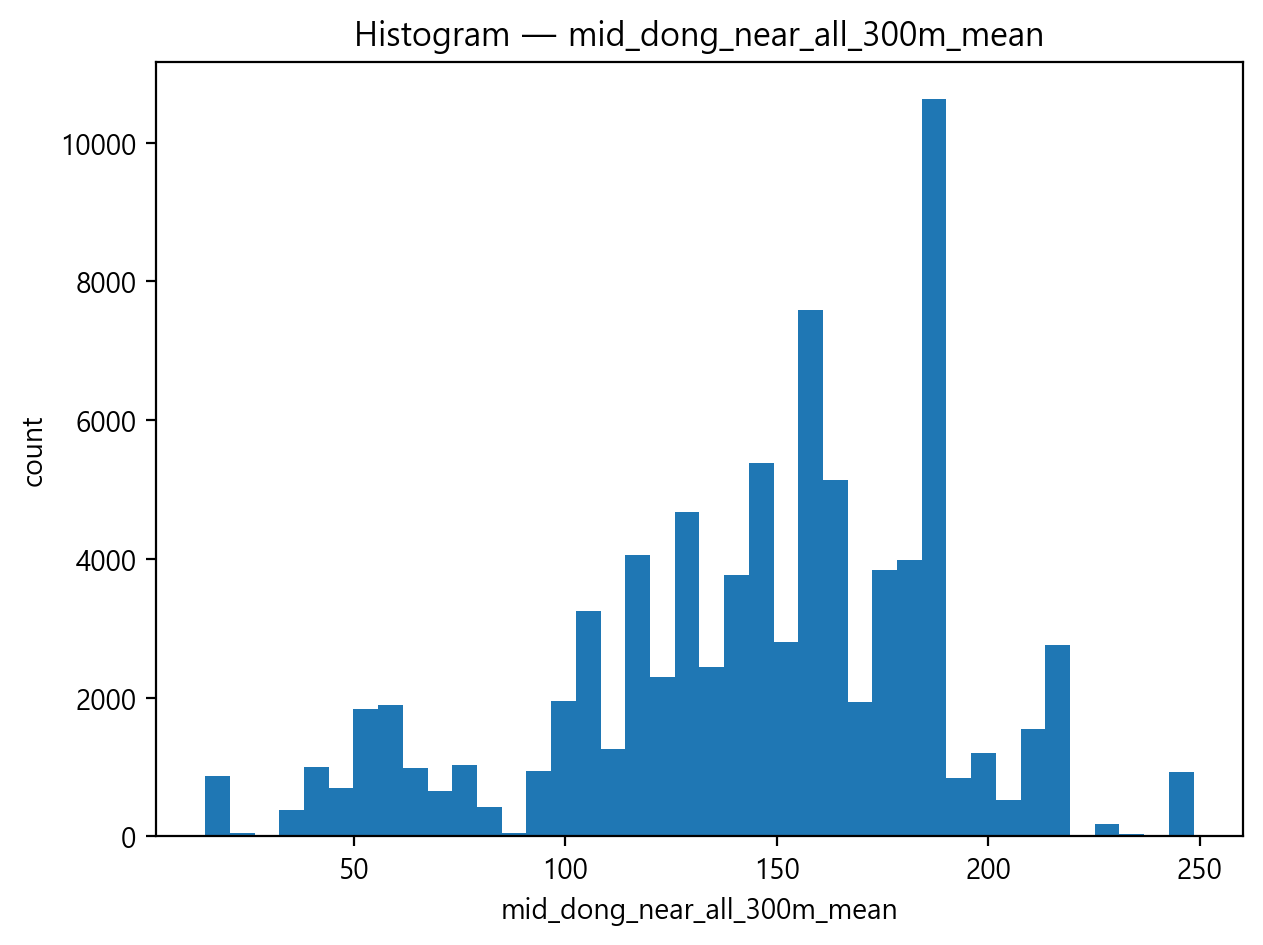

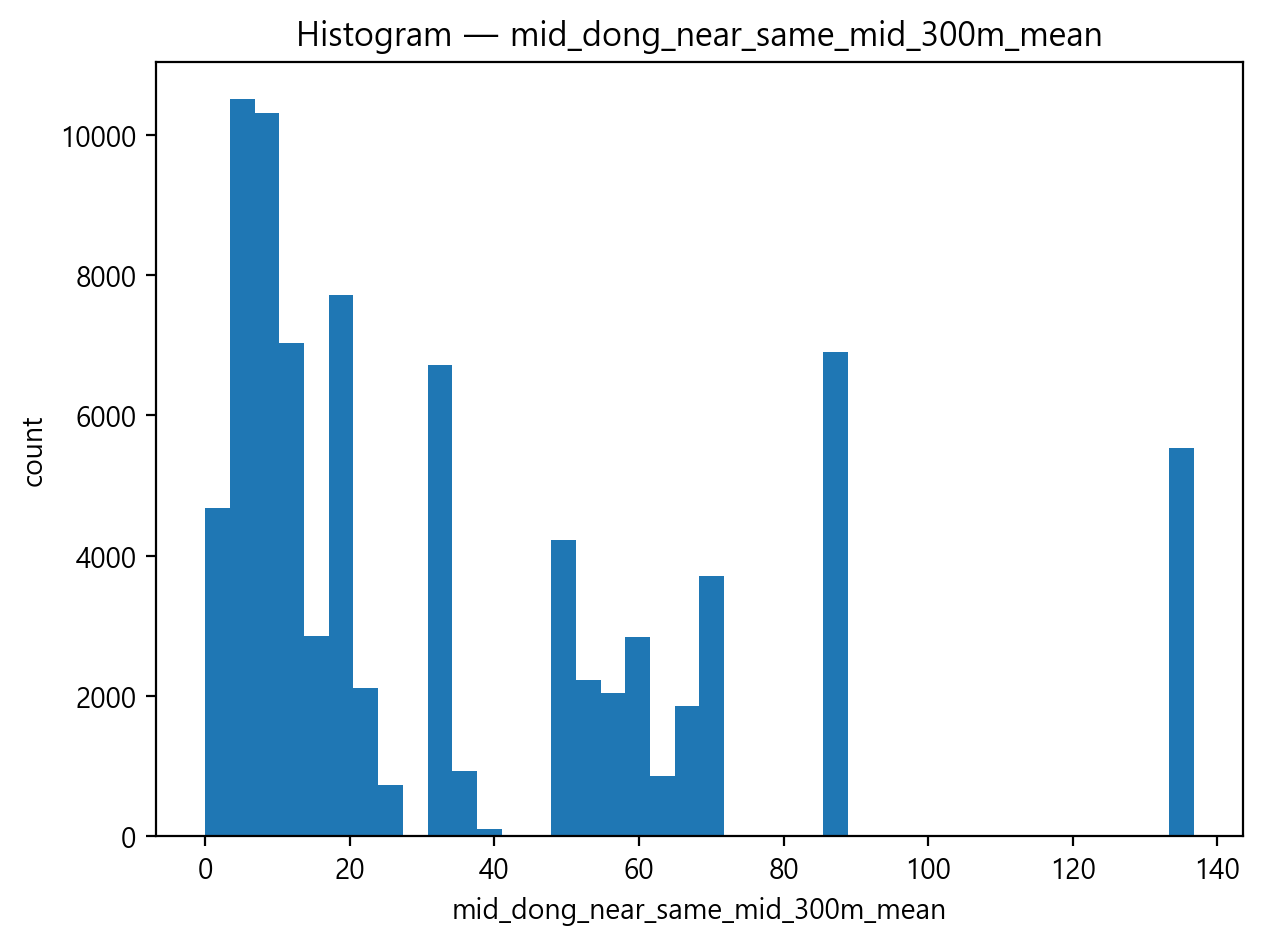

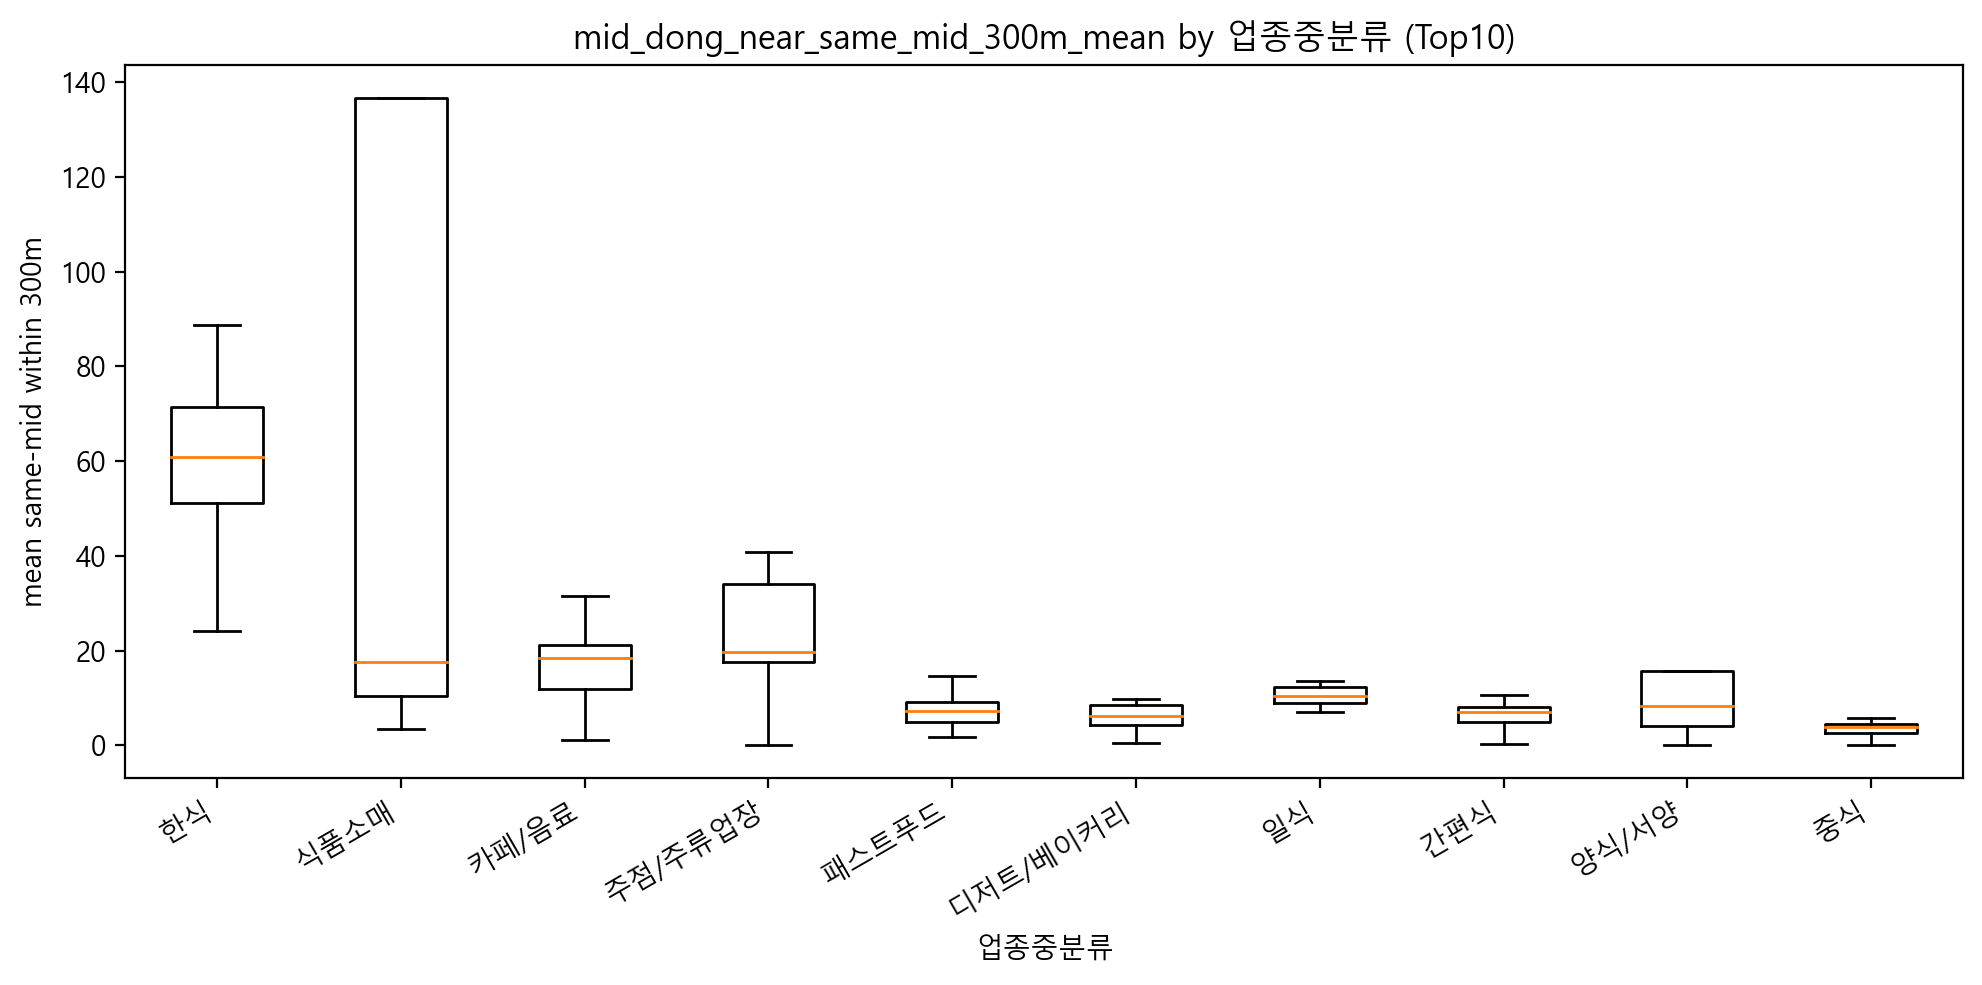

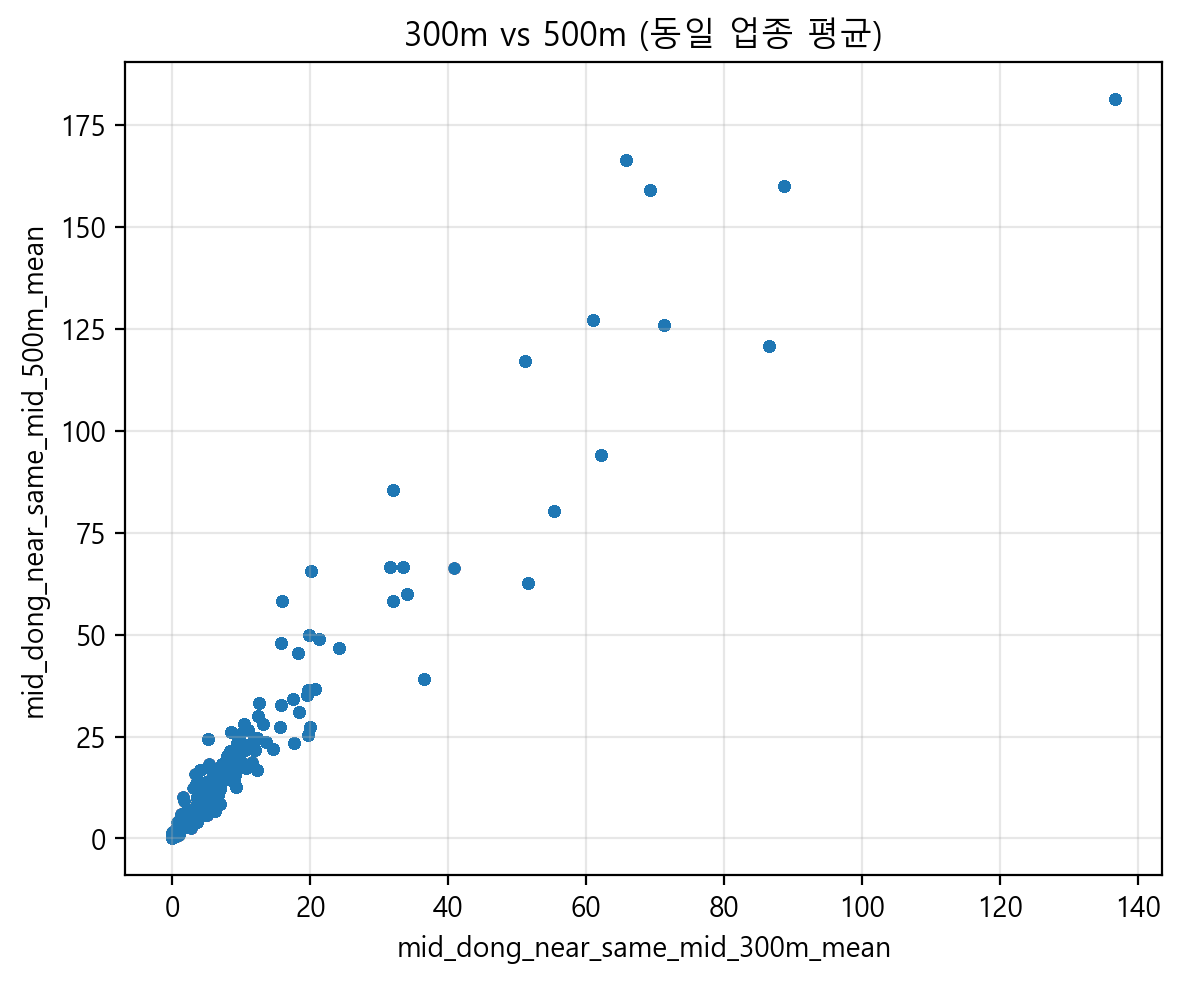

In [ ]:
# # 히스토그램
# for c in ["mid_dong_near_all_300m_mean","mid_dong_near_same_mid_300m_mean"]:
#     if c in df.columns:
#         s = pd.to_numeric(df[c], errors="coerce").dropna()
#         if len(s)>0:
#             plt.figure()
#             plt.hist(s, bins=40)
#             plt.title(f"Histogram — {c}")
#             plt.xlabel(c); plt.ylabel("count")
#             plt.tight_layout(); plt.show()

# # 업종별 박스플롯 (상위 10개 업종)
# if {"업종중분류","mid_dong_near_same_mid_300m_mean"}.issubset(df.columns):
#     top10 = df["업종중분류"].value_counts().head(10).index
#     sub = df[df["업종중분류"].isin(top10)]
#     data = [pd.to_numeric(sub.loc[sub["업종중분류"]==cat, "mid_dong_near_same_mid_300m_mean"], errors="coerce").dropna()
#             for cat in top10]
#     if any(len(d)>0 for d in data):
#         plt.figure(figsize=(10,5))
#         plt.boxplot(data, labels=list(top10), showfliers=False)
#         plt.title("mid_dong_near_same_mid_300m_mean by 업종중분류 (Top10)")
#         plt.xlabel("업종중분류"); plt.ylabel("mean same-mid within 300m")
#         plt.xticks(rotation=30, ha="right")
#         plt.tight_layout(); plt.show()

# # 3) 300m vs 500m 비교(산점도)
# if {"mid_dong_near_same_mid_300m_mean","mid_dong_near_same_mid_500m_mean"}.issubset(df.columns):
#     x = pd.to_numeric(df["mid_dong_near_same_mid_300m_mean"], errors="coerce")
#     y = pd.to_numeric(df["mid_dong_near_same_mid_500m_mean"], errors="coerce")
#     m = x.notna() & y.notna()
#     if m.any():
#         plt.figure(figsize=(6,5))
#         plt.scatter(x[m], y[m], s=10, alpha=0.5)
#         plt.title("300m vs 500m (동일 업종 평균)")
#         plt.xlabel("mid_dong_near_same_mid_300m_mean")
#         plt.ylabel("mid_dong_near_same_mid_500m_mean")
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout(); plt.show()

In [ ]:
# # 피어(업종×행정동) 내부 상대위치
# #  *_peer_mean_xs: 같은 업종×행정동 내부 평균
# #  *_z_peer_xs: (내 값 − 평균) / 표준편차 → 표준화 위치
# #  *_pct_peer_xs: 그룹 내 백분위(0~1)

# peer_vars = [x for x in ["share_new_row","cust_age_entropy","cust_source_entropy","거주 이용 고객 비율",
#                          "직장 이용 고객 비율","유동인구 이용 고객 비율","동일업종 해지가맹점 비중_press3",
#                          "동일상권 해지가맹점 비중_press3"] if x in df.columns]

# if peer_vars:
#     for c in peer_vars:
#         g = df.groupby(["업종중분류","행정동"])[c]
#         df[f"{c}_peer_mean_xs"] = g.transform("mean")
#         sd = g.transform("std").replace(0, np.nan)
#         df[f"{c}_z_peer_xs"]    = (df[c] - df[f"{c}_peer_mean_xs"]) / sd
#         df[f"{c}_pct_peer_xs"]  = g.rank(pct=True)

# # z-score 히스토그램 (예: share_new_row)
# plt.figure(figsize=(6,4))
# plt.hist(pd.to_numeric(df["share_new_row_z_peer_xs"], errors="coerce").dropna(), bins=40)
# plt.title("Histogram — share_new_row_z_peer_xs"); plt.xlabel("z-score"); plt.ylabel("rows")
# plt.tight_layout(); plt.show()

# # 백분위 박스플롯 (업종 상위 8개만)
# if {"share_new_row_pct_peer_xs","업종중분류"}.issubset(df.columns):
#     top8 = df["업종중분류"].value_counts().head(8).index
#     sub = df[df["업종중분류"].isin(top8)]
#     data = [pd.to_numeric(sub.loc[sub["업종중분류"]==cat, "share_new_row_pct_peer_xs"], errors="coerce").dropna()
#             for cat in top8]
#     if any(len(d)>0 for d in data):
#         plt.figure(figsize=(10,5))
#         plt.boxplot(data, labels=list(top8), showfliers=False)
#         plt.title("share_new_row_pct_peer_xs by 업종중분류 (Top8)")
#         plt.ylabel("percentile (0~1)")
#         plt.xticks(rotation=30, ha="right")
#         plt.tight_layout(); plt.show()

KeyError: 'share_new_row_z_peer_xs'

<Figure size 600x400 with 0 Axes>